## DP1 CDFS photometry diagnostics

This notebook validates the photometric behaviour of the LSST–VISTA Fusion Pipeline products in the CDFS/ECDFS region. The main catalogue contains LSST/ComCam optical forced photometry together with VISTA/VIRCAM near-infrared forced photometry, while the VIDEO public catalogue is used as an external reference for the near-infrared bands.

The notebook focuses on three practical validation questions:

1. How well do the DP1 near-infrared forced magnitudes agree with VIDEO photometry?
2. Are the residuals affected by cross-match ambiguity, deblending, aperture choice, or bright-end systematics?
3. Do the cleaned colour-colour diagrams show physically meaningful distributions after removing unreliable forced measurements?

A key point in this validation is that forced photometry must be interpreted on a per-band basis. A source can have a reliable measurement in one band and an unreliable or missing measurement in another band. Therefore, the notebook does not define one global “good source” mask. Instead, each diagnostic uses quality cuts only for the bands that enter that diagnostic.

For each DP1 band, the default quality mask requires finite magnitude, finite and positive magnitude uncertainty, an uncertainty below the adopted 5σ limit, and an unflagged aperture-flux measurement. If future catalogue versions include per-band coverage columns such as `g_has_valid_coverage` or `K_flux_usable`, the helper functions will use those columns automatically. In the current reduced catalogue, these coverage columns are not yet present, so the filtering is based on catalogue-level magnitude, uncertainty, and aperture-flux flags.

The residual plots compare DP1 and VIDEO measurements only when the relevant DP1 band passes the per-band quality mask and the corresponding VIDEO measurement is finite, unflagged, and has acceptable uncertainty. Additional match-quality diagnostics are included to test the effect of a smaller match radius and duplicated VIDEO counterparts. These stricter cuts are useful for identifying ambiguous matches, but they are interpreted separately from the full cleaned catalogue comparison.

The notebook also includes a VIDEO-star calibration diagnostic. This uses high-quality VIDEO stars to estimate a constant stellar offset in the `K_s` band and to test the dependence of the DP1–VIDEO residuals on the choice of VIDEO aperture. This stellar test is intended as a zero-point and aperture-consistency check, not as a replacement for the full galaxy+star residual validation.

Overall, the notebook provides a cleaned and reproducible set of photometric diagnostics for DP1 CDFS products, including residual comparisons, magnitude-distribution checks, colour-colour diagrams, stellar-offset tests, and bright-end residual trend diagnostics.

### 1. Imports, paths, and catalogue loading

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import astropy.units as u
from astropy.table import Table
from astropy.coordinates import SkyCoord, match_coordinates_sky

DATA_DIR = Path("../data")

DP1_PATH   = DATA_DIR / "full_reduced_cat_DP1_20260408.fits"
VIDEO_PATH = DATA_DIR / "VISTA-VIDEO-CDFS-DR5.fits"

OUTDIR = Path("data/plots_photometry")
OUTDIR.mkdir(parents=True, exist_ok=True)

# Photometric selection
MAGERR_5SIG = 2.5 / np.log(10) / 5.0
MAGERR_3SIG = 2.5 / np.log(10) / 3.0

# The previous diagnostic used this value to place DP1 NIR magnitudes
# approximately on the VIDEO system. Keep it explicit so it can be updated.
DP1_TO_VIDEO_OFFSET = 1.4

MATCH_RADIUS = 0.5 * u.arcsec
VIDEO_APER = 2

SAVE_FIGURES = True

dp1 = Table.read(DP1_PATH)
vid = Table.read(VIDEO_PATH)

print("DP1 rows :", len(dp1))
print("VIDEO rows:", len(vid))
print("DP1 columns:", len(dp1.colnames))
print("VIDEO columns:", len(vid.colnames))
print("Output directory:", OUTDIR)

DP1 rows : 1380173
VIDEO rows: 1138485
DP1 columns: 87
VIDEO columns: 389
Output directory: data/plots_photometry


### 2. Column definitions and per-band quality helpers

The most important part of this notebook is the function `dp1_band_usable`.

For each band, it requires:

- finite magnitude,
- finite magnitude error,
- positive magnitude error,
- magnitude error below the chosen limit,
- unflagged aperture-flux measurement,
- valid coverage **if a coverage column exists**.

In [2]:
DP1_PREFIX = {
    "u": "ComCam_u_m",
    "g": "ComCam_g_m",
    "r": "ComCam_r_m",
    "i": "ComCam_i_m",
    "z": "ComCam_z_m",
    "y": "ComCam_y_m",
    "Y": "VIRCAM_Y_m",
    "J": "VIRCAM_J_m",
    "H": "VIRCAM_H_m",
    "K": "VIRCAM_K_m",
}

VIDEO_PREFIX = {
    "Y": "Y",
    "J": "J",
    "H": "H",
    "K": "KS",
}

APER = "base_CircularApertureFlux_6_0"


def has_col(tab, col):
    return col in tab.colnames


def arr(tab, col, dtype=float):
    if col not in tab.colnames:
        raise KeyError(f"Missing column: {col}")
    return np.asarray(tab[col], dtype=dtype)


def dp1_cols(band):
    prefix = DP1_PREFIX[band]
    return {
        "mag":  f"{prefix}_{APER}_mag",
        "err":  f"{prefix}_{APER}_magErr",
        "flag": f"{prefix}_{APER}_flag",
        "ra":   f"{prefix}_coord_ra",
        "dec":  f"{prefix}_coord_dec",
        # optional future columns
        "coverage": f"{band}_has_valid_coverage",
        "usable":   f"{band}_flux_usable",
    }


def dp1_mag(tab, band):
    return arr(tab, dp1_cols(band)["mag"], float)


def dp1_err(tab, band):
    return arr(tab, dp1_cols(band)["err"], float)


def dp1_flag(tab, band):
    col = dp1_cols(band)["flag"]
    if has_col(tab, col):
        return arr(tab, col, bool)
    return np.zeros(len(tab), dtype=bool)


def dp1_has_coverage_col(tab, band):
    return has_col(tab, dp1_cols(band)["coverage"])


def dp1_has_usable_col(tab, band):
    return has_col(tab, dp1_cols(band)["usable"])


def dp1_band_usable(tab, band, err_lim=MAGERR_5SIG, require_flag=True, require_coverage=True):
    '''
    Per-band DP1 usability mask.

    This does not define a globally good object. It only says whether
    the selected band can be used in a diagnostic.
    '''
    # If a precomputed flux-usable column exists, use it directly.
    # This is the preferred option for final catalogues.
    usable_col = dp1_cols(band)["usable"]
    if require_coverage and has_col(tab, usable_col):
        return arr(tab, usable_col, bool)

    mag = dp1_mag(tab, band)
    err = dp1_err(tab, band)

    m = (
        np.isfinite(mag)
        & np.isfinite(err)
        & (err > 0)
        & (err < err_lim)
    )

    if require_flag:
        m &= ~dp1_flag(tab, band)

    # Use optional per-band coverage if available.
    cov_col = dp1_cols(band)["coverage"]
    if require_coverage and has_col(tab, cov_col):
        m &= arr(tab, cov_col, bool)

    return m


def dp1_colour(tab, band1, band2):
    return dp1_mag(tab, band1) - dp1_mag(tab, band2)


def nmad(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan
    med = np.nanmedian(x)
    return 1.4826 * np.nanmedian(np.abs(x - med))


def qstats(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.array([np.nan, np.nan, np.nan, np.nan, np.nan])
    return np.nanpercentile(x, [5, 16, 50, 84, 95])


def savefig(filename, dpi=300):
    """
    Save figure to data/plots_photometry if SAVE_FIGURES=True.
    """
    if SAVE_FIGURES:
        plt.savefig(
            OUTDIR / filename,
            dpi=dpi,
            bbox_inches="tight",
        )

### 3. Band summary

This gives a quick view of how many rows pass the per-band catalogue-level quality mask. If coverage columns are not present in the reduced catalogue, this is a magnitude/error/aperture-flag summary.

In [3]:
def band_summary(tab, band):
    mag = dp1_mag(tab, band)
    err = dp1_err(tab, band)
    flag = dp1_flag(tab, band)

    finite = np.isfinite(mag) & np.isfinite(err)
    unflagged = finite & (~flag)
    usable = dp1_band_usable(tab, band, err_lim=MAGERR_5SIG, require_coverage=True)

    print(f"Band {band}")
    print(f"  finite mag/err       : {finite.sum():8d} / {len(tab)}")
    print(f"  finite and unflagged : {unflagged.sum():8d} / {len(tab)}")
    print(f"  usable 5-sigma       : {usable.sum():8d} / {len(tab)}")
    print(f"  has coverage column  : {dp1_has_coverage_col(tab, band)}")
    print(f"  has usable column    : {dp1_has_usable_col(tab, band)}")
    if usable.sum() > 0:
        print(f"  mag range usable     : {np.nanmin(mag[usable]):.3f} to {np.nanmax(mag[usable]):.3f}")
        print(f"  median err usable    : {np.nanmedian(err[usable]):.5f}")
    print()

for band in ["Y", "J", "H", "K", "u", "g", "r", "i", "z", "y"]:
    if band in DP1_PREFIX and has_col(dp1, dp1_cols(band)["mag"]):
        band_summary(dp1, band)

Band Y
  finite mag/err       :  1166402 / 1380173
  finite and unflagged :   601978 / 1380173
  usable 5-sigma       :   555904 / 1380173
  has coverage column  : False
  has usable column    : False
  mag range usable     : 13.615 to 28.102
  median err usable    : 0.03888

Band J
  finite mag/err       :  1182800 / 1380173
  finite and unflagged :   554715 / 1380173
  usable 5-sigma       :   477656 / 1380173
  has coverage column  : False
  has usable column    : False
  mag range usable     : 14.970 to 27.483
  median err usable    : 0.04783

Band H
  finite mag/err       :  1149296 / 1380173
  finite and unflagged :   515508 / 1380173
  usable 5-sigma       :   430729 / 1380173
  has coverage column  : False
  has usable column    : False
  mag range usable     : 14.922 to 26.808
  median err usable    : 0.05178

Band K
  finite mag/err       :  1129110 / 1380173
  finite and unflagged :   456534 / 1380173
  usable 5-sigma       :   351845 / 1380173
  has coverage column  : False

### 4. Coordinates and DP1--VIDEO cross-match

The cross-match is built once and then reused for all residual plots.

DP1 coordinates are taken from the `K` catalogue coordinates, because this notebook is mainly validating the K-selected / NIR reference catalogue against VIDEO.

In [4]:
DP1_RA  = "VIRCAM_K_m_coord_ra"   # radians in the DP1 table
DP1_DEC = "VIRCAM_K_m_coord_dec"  # radians in the DP1 table
VID_RA  = "RA2000"                # degrees
VID_DEC = "DEC2000"               # degrees

ra_dp1  = np.asarray(dp1[DP1_RA], dtype=float)
dec_dp1 = np.asarray(dp1[DP1_DEC], dtype=float)
m_dp1_coord = np.isfinite(ra_dp1) & np.isfinite(dec_dp1)

dp1c = dp1[m_dp1_coord]
c_dp1 = SkyCoord(
    ra=ra_dp1[m_dp1_coord] * u.rad,
    dec=dec_dp1[m_dp1_coord] * u.rad,
    frame="icrs",
)

ra_vid  = np.asarray(vid[VID_RA], dtype=float)
dec_vid = np.asarray(vid[VID_DEC], dtype=float)
m_vid_coord = np.isfinite(ra_vid) & np.isfinite(dec_vid)

vidc = vid[m_vid_coord]
c_vid = SkyCoord(
    ra=ra_vid[m_vid_coord] * u.deg,
    dec=dec_vid[m_vid_coord] * u.deg,
    frame="icrs",
)

print("Finite coordinates:")
print("  DP1  :", len(dp1c), "/", len(dp1))
print("  VIDEO:", len(vidc), "/", len(vid))

# Restrict VIDEO to the DP1 footprint for faster matching.
ra_dp1_deg = np.degrees(ra_dp1[m_dp1_coord])
dec_dp1_deg = np.degrees(dec_dp1[m_dp1_coord])

ra_min, ra_max = np.nanpercentile(ra_dp1_deg, [0.5, 99.5])
dec_min, dec_max = np.nanpercentile(dec_dp1_deg, [0.5, 99.5])

pad = 0.02
ra_min -= pad
ra_max += pad
dec_min -= pad
dec_max += pad

in_box = (
    (ra_vid[m_vid_coord] >= ra_min)
    & (ra_vid[m_vid_coord] <= ra_max)
    & (dec_vid[m_vid_coord] >= dec_min)
    & (dec_vid[m_vid_coord] <= dec_max)
)

vid_box = vidc[in_box]
c_vid_box = c_vid[in_box]

print("VIDEO rows in DP1 box:", len(vid_box))

idx, sep, _ = match_coordinates_sky(c_dp1, c_vid_box)
matched = sep < MATCH_RADIUS

print(f"Matches within {MATCH_RADIUS.to(u.arcsec).value:.2f} arcsec:", int(matched.sum()))

Finite coordinates:
  DP1  : 1380173 / 1380173
  VIDEO: 1138485 / 1138485
VIDEO rows in DP1 box: 552377
Matches within 0.50 arcsec: 770159


### 5. Baseline residual plots: sep < 0.50 arcsec

Residual plots should be filtered using the same per-band logic.

For a residual in band `X`, this notebook requires:

- DP1 `X` magnitude and error are finite,
- DP1 `X` magnitude error is below the threshold,
- DP1 `X` aperture flux is unflagged,
- DP1 `X` valid coverage if a coverage column exists,
- VIDEO `X` magnitude and error are finite,
- VIDEO `X` error is below the threshold,
- VIDEO flag is zero if a flag column exists.

This is important because no-data forced measurements can also produce large residual scatter.

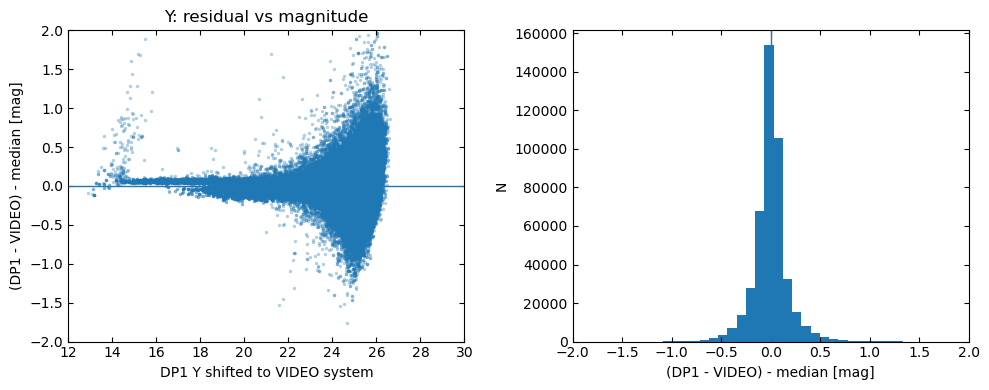

Y band
  VIDEO column: Y_MAG_APER_2
  magErr threshold: 0.217
  N: 449966
  median(DP1 - VIDEO): 0.07068785251415477
  NMAD(res): 0.10402808423256127
  bright N (DP1 shifted mag < 18): 2544
  bright NMAD(res): 0.0158936425388083
  bright frac |res| > 0.3: 0.0330188679245283


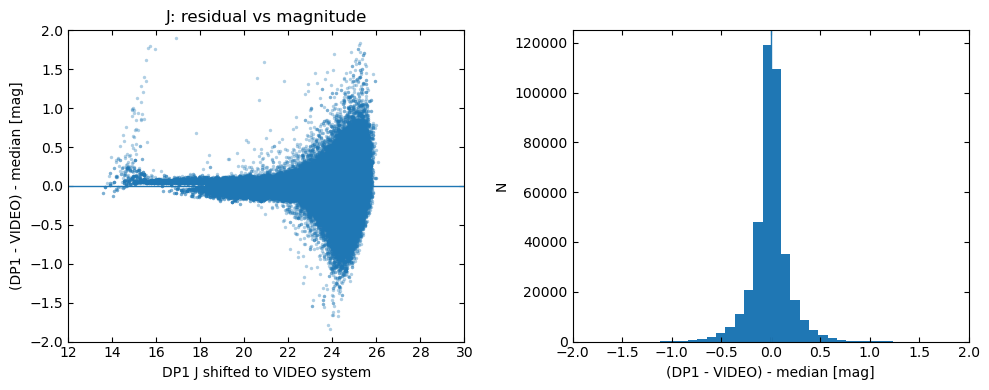

J band
  VIDEO column: J_MAG_APER_2
  magErr threshold: 0.217
  N: 392156
  median(DP1 - VIDEO): 0.05763179750327296
  NMAD(res): 0.10813332829318163
  bright N (DP1 shifted mag < 18): 2798
  bright NMAD(res): 0.014863968649161986
  bright frac |res| > 0.3: 0.023230879199428164


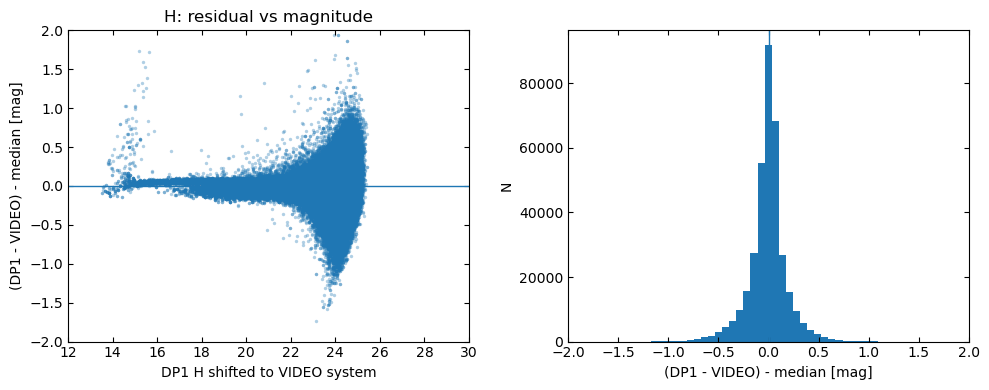

H band
  VIDEO column: H_MAG_APER_2
  magErr threshold: 0.217
  N: 353991
  median(DP1 - VIDEO): 0.060815870217115986
  NMAD(res): 0.113041780126486
  bright N (DP1 shifted mag < 18): 3144
  bright NMAD(res): 0.01992335364194059
  bright frac |res| > 0.3: 0.02703562340966921


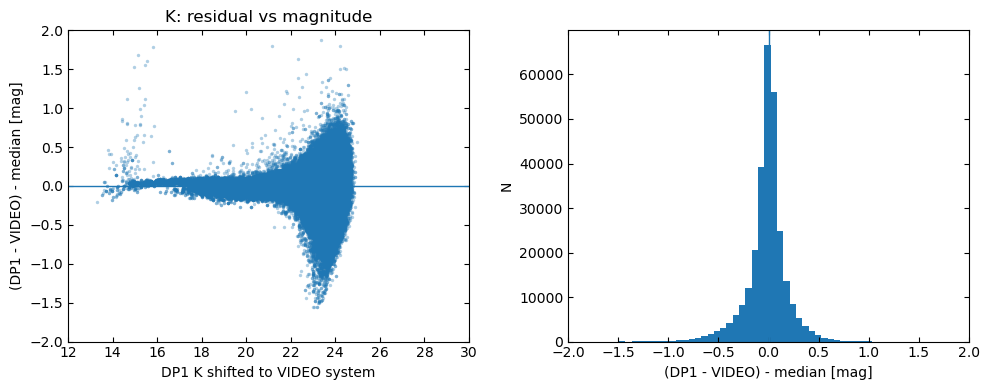

K band
  VIDEO column: KS_MAG_APER_2
  magErr threshold: 0.217
  N: 285558
  median(DP1 - VIDEO): 0.060679916914889276
  NMAD(res): 0.11351276121133709
  bright N (DP1 shifted mag < 18): 2879
  bright NMAD(res): 0.024620535568880303
  bright frac |res| > 0.3: 0.019451198332754428


In [5]:
def video_cols(prefix, aper=VIDEO_APER):
    return {
        "mag":  f"{prefix}_MAG_APER_{aper}",
        "err":  f"{prefix}_MAGERR_APER_{aper}",
        "flag": f"{prefix}_FLAGS",
    }


def video_good_mask(tab, prefix, aper=VIDEO_APER, err_lim=MAGERR_5SIG, require_flag=True):
    cols = video_cols(prefix, aper=aper)

    if not has_col(tab, cols["mag"]):
        raise KeyError(f"Missing VIDEO magnitude column: {cols['mag']}")

    mag = arr(tab, cols["mag"], float)

    if has_col(tab, cols["err"]):
        err = arr(tab, cols["err"], float)
        m = np.isfinite(mag) & np.isfinite(err) & (err > 0) & (err < err_lim)
    else:
        m = np.isfinite(mag)

    if require_flag and has_col(tab, cols["flag"]):
        flag = arr(tab, cols["flag"], int)
        m &= (flag == 0)

    return m


def compare_residual_band(
    band,
    aper=VIDEO_APER,
    dp1_to_video_offset=DP1_TO_VIDEO_OFFSET,
    err_lim=MAGERR_5SIG,
    xlim=(12, 30),
    ylim=(-2, 2),
):
    if band not in VIDEO_PREFIX:
        raise ValueError(f"No VIDEO mapping for band {band}")

    vprefix = VIDEO_PREFIX[band]
    vcols = video_cols(vprefix, aper=aper)

    if not has_col(vid_box, vcols["mag"]):
        print(f"Skipping {band}: missing VIDEO column {vcols['mag']}")
        return None

    dp1_m = dp1_mag(dp1c, band) - dp1_to_video_offset
    dp1_good = dp1_band_usable(dp1c, band, err_lim=err_lim, require_coverage=True)

    vid_m_all = arr(vid_box, vcols["mag"], float)
    vid_good_all = video_good_mask(vid_box, vprefix, aper=aper, err_lim=err_lim, require_flag=True)

    good = (
        matched
        & dp1_good
        & vid_good_all[idx]
        & np.isfinite(dp1_m)
        & np.isfinite(vid_m_all[idx])
    )

    if good.sum() == 0:
        print(f"{band}: no good matched sources")
        return None

    dm = dp1_m[good] - vid_m_all[idx[good]]
    const = np.nanmedian(dm)
    res = dm - const
    mag_plot = dp1_m[good]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].scatter(mag_plot, res, s=6, alpha=0.35, linewidths=0)
    axes[0].axhline(0, lw=1)
    axes[0].set_xlim(*xlim)
    axes[0].set_ylim(*ylim)
    axes[0].set_xlabel(f"DP1 {band} shifted to VIDEO system")
    axes[0].set_ylabel("(DP1 - VIDEO) - median [mag]")
    axes[0].set_title(f"{band}: residual vs magnitude")
    axes[0].tick_params(direction="in", top=True, right=True)

    axes[1].hist(res[np.isfinite(res)], bins=60)
    axes[1].axvline(0, lw=1)
    axes[1].set_xlim(*ylim)
    axes[1].set_xlabel("(DP1 - VIDEO) - median [mag]")
    axes[1].set_ylabel("N")
    axes[1].tick_params(direction="in", top=True, right=True)

    plt.tight_layout()
    savefig(f"dp1_video_{band}_residuals.png")
    plt.show()

    print(f"{band} band")
    print("  VIDEO column:", vcols["mag"])
    print(f"  magErr threshold: {err_lim:.3f}")
    print("  N:", int(good.sum()))
    print("  median(DP1 - VIDEO):", float(const))
    print("  NMAD(res):", float(nmad(res)))

    bright = mag_plot < 18
    if bright.sum() > 0:
        print("  bright N (DP1 shifted mag < 18):", int(bright.sum()))
        print("  bright NMAD(res):", float(nmad(res[bright])))
        print("  bright frac |res| > 0.3:", float(np.mean(np.abs(res[bright]) > 0.3)))

    return {
        "band": band,
        "mask": good,
        "mag": mag_plot,
        "res": res,
        "median": const,
        "nmad": nmad(res),
    }


residual_results = {}
for band in ["Y", "J", "H", "K"]:
    try:
        result = compare_residual_band(band, err_lim=MAGERR_5SIG)
        if result is not None:
            residual_results[band] = result
    except Exception as e:
        print(f"Skipping {band} because of error:")
        print(type(e).__name__, e)

### 6. Residual summary table

This gives a compact comparison of the cleaned residuals in each NIR band.

If bright scatter remains after these cuts, the next causes to check are saturation, deblending, duplicate rows, aperture choice, or calibration offsets. If coverage columns are not available in the reduced catalogue, rerun this after adding them.

In [6]:
print("Band   N       median(DP1-VIDEO)    NMAD")
for band, result in residual_results.items():
    print(
        f"{band:4s} "
        f"{len(result['res']):7d} "
        f"{result['median']:18.5f} "
        f"{result['nmad']:10.5f}"
    )

Band   N       median(DP1-VIDEO)    NMAD
Y     449966            0.07069    0.10403
J     392156            0.05763    0.10813
H     353991            0.06082    0.11304
K     285558            0.06068    0.11351


### Diagnostic check 1
The main bright locus is actually good, but there is still a strange small outlier population between about 14–16 mag in most bands. The numbers show this clearly:

>Y bright NMAD ≈ 0.016 mag, |res| > 0.3 fraction ≈ 3.3%
>
>J bright NMAD ≈ 0.015 mag, |res| > 0.3 fraction ≈ 2.3%
>
>H bright NMAD ≈ 0.020 mag, |res| > 0.3 fraction ≈ 2.7%
>
>K bright NMAD ≈ 0.025 mag, |res| > 0.3 fraction ≈ 1.9%

So the bulk bright photometry is fine, but the plume/outliers around 14–16 mag are real and should be diagnosed. It is more likely one of these:

- Duplicate/multiple DP1 sources matched to the same VIDEO object:
This is very likely. In the suspicious table I already saw repeated coordinates and multiple DP1 rows around the same VIDEO source for some bright problematic cases. Some were classified as K_photometry_disagrees_with_VIDEO.
- Bright extended galaxies or deblended sources:
VIDEO aperture photometry and DP1 aperture photometry may measure different parts of a large/complex object.
- Saturation, interpolation, or masking not captured by the aperture-flux flag:
The aperture flag is useful, but it may not remove every bright-object problem.
- Cross-match ambiguity:
A 0.5 arcsec match is usually fine, but around bright/extended sources, several DP1 children can match one VIDEO object.

In [7]:
# ------------------------------------------------------------
# Bright residual outlier diagnostic
# ------------------------------------------------------------

def bright_outlier_diagnostic(band, result, bright_mag_lim=18, outlier_lim=0.3):
    good = result["mask"]
    mag = result["mag"]
    res = result["res"]

    # These are arrays only for the matched-good sample,
    # so reconstruct the selected row indices.
    selected_dp1_rows = np.where(good)[0]
    selected_video_rows = idx[good]

    bright = mag < bright_mag_lim
    outlier = bright & (np.abs(res) > outlier_lim)

    print(f"\n{band} bright outlier diagnostic")
    print("N bright:", int(bright.sum()))
    print("N bright outliers:", int(outlier.sum()))
    print("fraction:", outlier.sum() / bright.sum() if bright.sum() > 0 else np.nan)

    if outlier.sum() == 0:
        return None

    dp1_rows = selected_dp1_rows[outlier]
    video_rows = selected_video_rows[outlier]

    # Check duplicate VIDEO matches
    unique_vid, counts = np.unique(video_rows, return_counts=True)
    duplicate_video_ids = unique_vid[counts > 1]
    duplicated = np.isin(video_rows, duplicate_video_ids)

    print("N outliers matched to duplicated VIDEO objects:", int(duplicated.sum()))
    print("fraction duplicated:", np.mean(duplicated))

    # Match separation
    sep_arcsec = sep[good][outlier].arcsec
    print("median separation [arcsec]:", np.nanmedian(sep_arcsec))
    print("90th percentile separation [arcsec]:", np.nanpercentile(sep_arcsec, 90))

    # Print strongest outliers
    order = np.argsort(np.abs(res[outlier]))[::-1]

    print("\nStrongest bright outliers:")
    print("DP1_row  VIDEO_row  mag  res  sep_arcsec")
    for jj in order[:20]:
        print(
            f"{dp1_rows[jj]:8d} "
            f"{video_rows[jj]:9d} "
            f"{mag[outlier][jj]:8.3f} "
            f"{res[outlier][jj]:+8.3f} "
            f"{sep_arcsec[jj]:8.3f}"
        )

    return {
        "dp1_rows": dp1_rows,
        "video_rows": video_rows,
        "res": res[outlier],
        "mag": mag[outlier],
        "sep_arcsec": sep_arcsec,
        "duplicated_video_match": duplicated,
    }


bright_outliers = {}

for band, result in residual_results.items():
    bright_outliers[band] = bright_outlier_diagnostic(band, result)


Y bright outlier diagnostic
N bright: 2544
N bright outliers: 84
fraction: 0.0330188679245283
N outliers matched to duplicated VIDEO objects: 37
fraction duplicated: 0.44047619047619047
median separation [arcsec]: 0.23598267369690007
90th percentile separation [arcsec]: 0.42892408794013703

Strongest bright outliers:
DP1_row  VIDEO_row  mag  res  sep_arcsec
  722476    173093   16.148   +2.140    0.449
  506340    173093   16.143   +2.135    0.450
  719688    163069   15.266   +2.121    0.216
  732057    139178   15.482   +1.894    0.315
  177824    140137   15.185   +1.699    0.035
 1334550    139178   15.269   +1.680    0.430
  124732    181479   14.848   +1.607    0.410
  960979     69912   14.899   +1.437    0.126
 1019664    103924   14.814   +1.283    0.358
  579566    220891   15.135   +1.282    0.107
  539666    248799   15.825   +1.207    0.323
  989624    140137   14.690   +1.204    0.147
   34914    124166   14.813   +1.128    0.435
  480898    124166   14.673   +0.987    0


- The large outliers around 14–16 mag are partly caused by duplicate VIDEO matches. About 44–57% of the bright outliers are matched to duplicated VIDEO objects, depending on the band. Also, many have relatively large separations, with 90th-percentile separations around 0.42–0.44 arcsec.

### Diagnostic check 2
Looking at the plot, the residuals around 16–18 still seem slightly more positive than negative. It may be a small magnitude-dependent trend.

The next useful check is to measure the median residual in magnitude bins.


Y residual trend by magnitude
mag_bin        N    median_res    NMAD_res    frac_positive
13.0-13.5      21     +0.0296     0.1838      0.571
13.5-14.0      34     +0.1054     0.1401      0.824
14.0-14.5      95     +0.1340     0.1068      1.000
14.5-15.0     126     +0.0643     0.0280      1.000
15.0-15.5     161     +0.0612     0.0184      1.000
15.5-16.0     227     +0.0615     0.0146      1.000
16.0-16.5     325     +0.0605     0.0143      1.000
16.5-17.0     393     +0.0585     0.0116      0.975
17.0-17.5     480     +0.0617     0.0157      0.944
17.5-18.0     681     +0.0604     0.0147      0.922
18.0-18.5     825     +0.0564     0.0181      0.845
18.5-19.0    1327     +0.0536     0.0224      0.729
19.0-19.5    1710     +0.0512     0.0329      0.667
19.5-20.0    2504     +0.0141     0.0686      0.553
20.0-20.5    4210     +0.0014     0.0714      0.507
20.5-21.0    6627     -0.0026     0.0633      0.485
21.0-21.5    9916     -0.0011     0.0528      0.492
21.5-22.0   14545     +0.

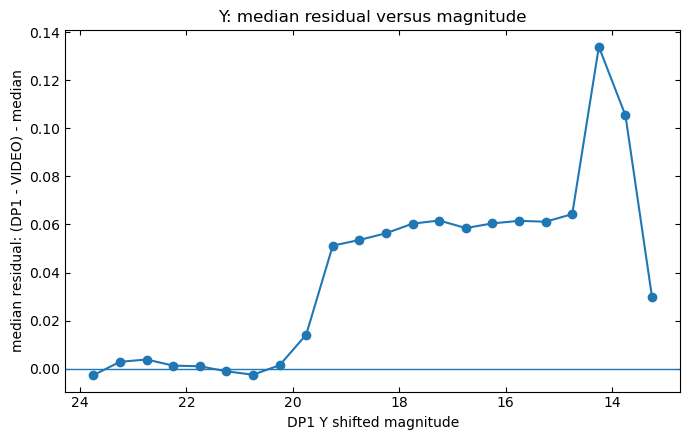

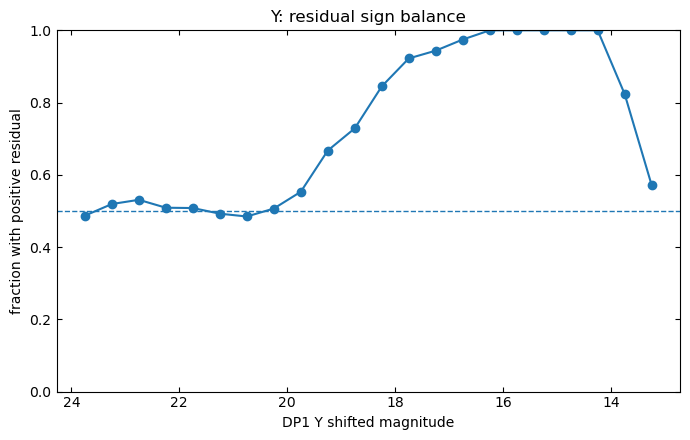


J residual trend by magnitude
mag_bin        N    median_res    NMAD_res    frac_positive
13.5-14.0      17     +0.0122     0.0372      0.647
14.0-14.5      43     +0.1182     0.1943      0.698
14.5-15.0     141     +0.1068     0.1109      0.979
15.0-15.5     221     +0.0741     0.0388      1.000
15.5-16.0     253     +0.0575     0.0141      1.000
16.0-16.5     342     +0.0606     0.0121      0.982
16.5-17.0     410     +0.0587     0.0146      0.951
17.0-17.5     582     +0.0572     0.0134      0.930
17.5-18.0     789     +0.0566     0.0141      0.869
18.0-18.5    1071     +0.0528     0.0202      0.755
18.5-19.0    1552     +0.0502     0.0290      0.684
19.0-19.5    2156     +0.0392     0.0511      0.582
19.5-20.0    3586     +0.0028     0.0710      0.511
20.0-20.5    5482     -0.0004     0.0646      0.497
20.5-21.0    8980     -0.0012     0.0525      0.491
21.0-21.5   12824     +0.0023     0.0484      0.519
21.5-22.0   18839     +0.0006     0.0502      0.504
22.0-22.5   26450     +0.

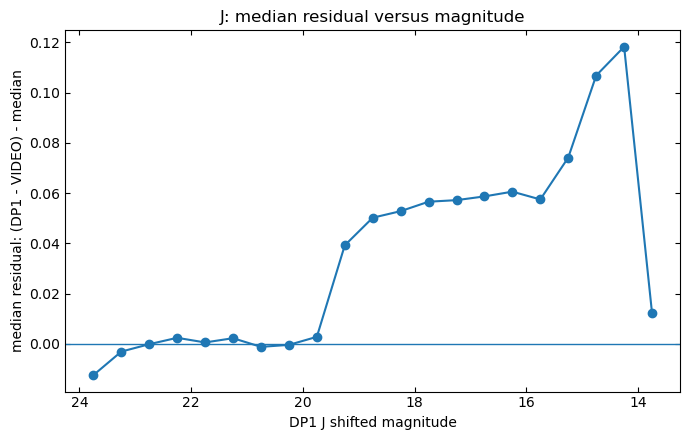

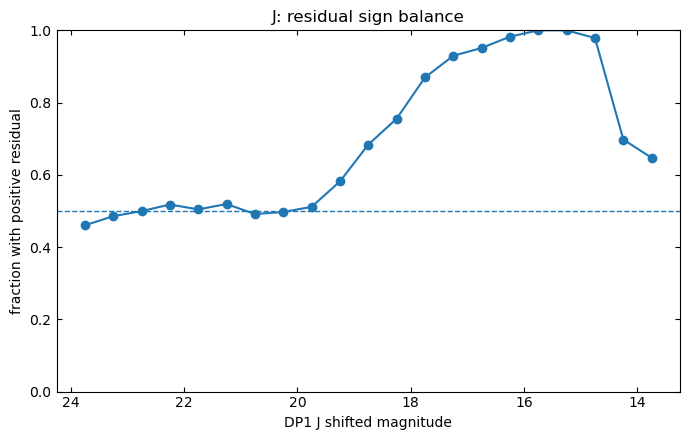


H residual trend by magnitude
mag_bin        N    median_res    NMAD_res    frac_positive
13.5-14.0      43     -0.0577     0.0731      0.349
14.0-14.5      67     +0.0258     0.1206      0.597
14.5-15.0     198     +0.0612     0.0828      0.859
15.0-15.5     223     +0.0378     0.0192      0.960
15.5-16.0     265     +0.0494     0.0156      0.985
16.0-16.5     384     +0.0530     0.0146      0.984
16.5-17.0     452     +0.0510     0.0167      0.934
17.0-17.5     661     +0.0524     0.0182      0.912
17.5-18.0     851     +0.0486     0.0215      0.804
18.0-18.5    1310     +0.0438     0.0358      0.682
18.5-19.0    1859     +0.0374     0.0533      0.607
19.0-19.5    2920     -0.0029     0.0686      0.484
19.5-20.0    4622     +0.0003     0.0590      0.501
20.0-20.5    7856     -0.0010     0.0491      0.492
20.5-21.0   11259     +0.0041     0.0465      0.537
21.0-21.5   15989     +0.0033     0.0471      0.530
21.5-22.0   22218     +0.0036     0.0519      0.528
22.0-22.5   30711     +0.

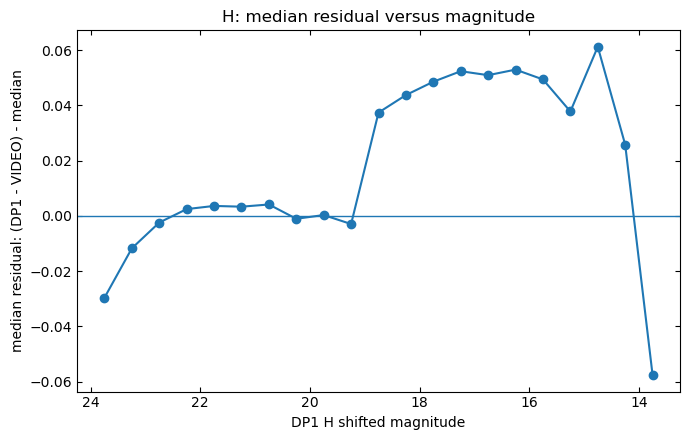

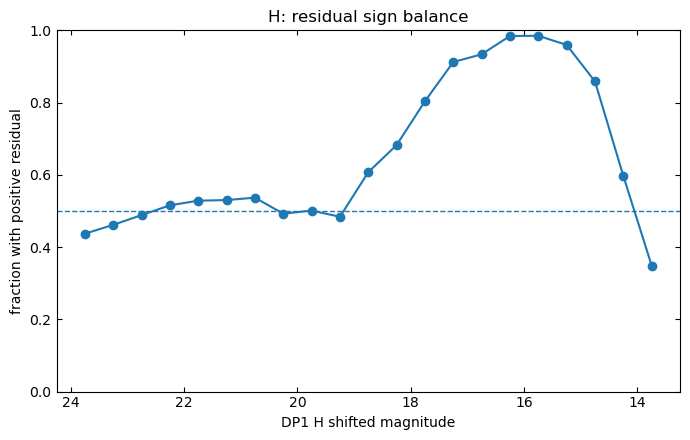


K residual trend by magnitude
mag_bin        N    median_res    NMAD_res    frac_positive
13.5-14.0      30     -0.0615     0.0346      0.233
14.0-14.5      49     -0.0000     0.1558      0.490
14.5-15.0     150     +0.0340     0.0456      0.867
15.0-15.5     165     +0.0322     0.0243      0.909
15.5-16.0     209     +0.0420     0.0153      1.000
16.0-16.5     313     +0.0422     0.0143      0.974
16.5-17.0     400     +0.0457     0.0184      0.925
17.0-17.5     635     +0.0435     0.0225      0.839
17.5-18.0     927     +0.0382     0.0329      0.723
18.0-18.5    1429     +0.0338     0.0580      0.598
18.5-19.0    2283     +0.0091     0.0588      0.542
19.0-19.5    3741     -0.0026     0.0545      0.485
19.5-20.0    6634     -0.0039     0.0460      0.461
20.0-20.5   10310     +0.0023     0.0461      0.521
20.5-21.0   14322     +0.0070     0.0450      0.563
21.0-21.5   19355     +0.0062     0.0513      0.550
21.5-22.0   25729     +0.0064     0.0658      0.538
22.0-22.5   32914     +0.

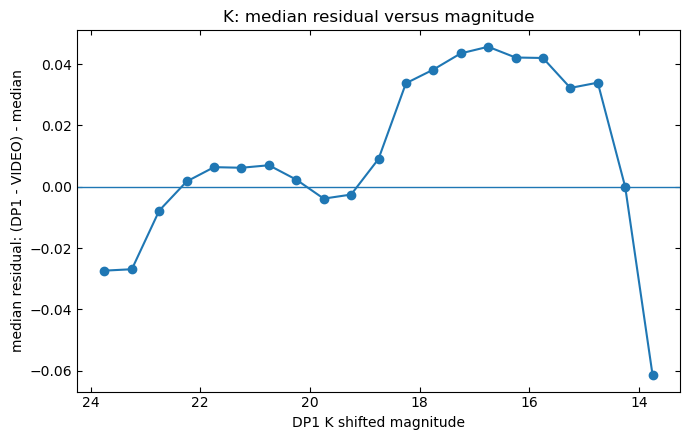

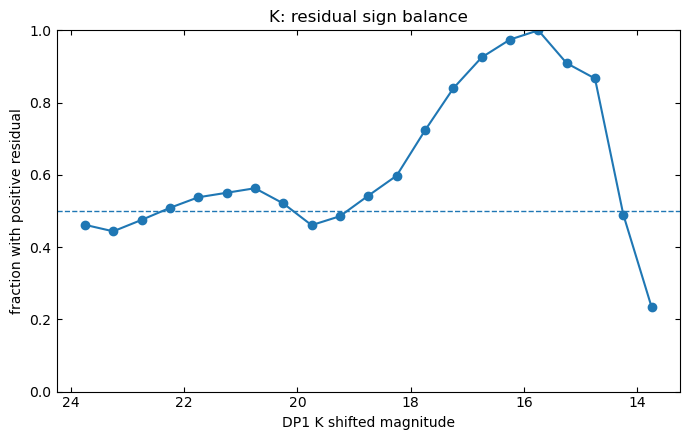

In [8]:
def residual_trend_by_mag(result, band, bins=np.arange(13, 24.5, 0.5)):
    mag = result["mag"]
    res = result["res"]

    print(f"\n{band} residual trend by magnitude")
    print("mag_bin        N    median_res    NMAD_res    frac_positive")

    bin_centres = []
    medians = []
    nmads = []
    counts = []
    frac_pos = []

    for lo, hi in zip(bins[:-1], bins[1:]):
        m = (
            np.isfinite(mag)
            & np.isfinite(res)
            & (mag >= lo)
            & (mag < hi)
        )

        if m.sum() < 10:
            continue

        med = np.nanmedian(res[m])
        scat = nmad(res[m])
        fp = np.mean(res[m] > 0)

        bin_centres.append(0.5 * (lo + hi))
        medians.append(med)
        nmads.append(scat)
        counts.append(m.sum())
        frac_pos.append(fp)

        print(
            f"{lo:4.1f}-{hi:4.1f}  "
            f"{m.sum():6d}  "
            f"{med:+10.4f}  "
            f"{scat:9.4f}  "
            f"{fp:9.3f}"
        )

    bin_centres = np.asarray(bin_centres)
    medians = np.asarray(medians)
    nmads = np.asarray(nmads)
    frac_pos = np.asarray(frac_pos)

    plt.figure(figsize=(7, 4.5))
    plt.axhline(0, lw=1)
    plt.plot(bin_centres, medians, marker="o")
    plt.xlabel(f"DP1 {band} shifted magnitude")
    plt.ylabel("median residual: (DP1 - VIDEO) - median")
    plt.title(f"{band}: median residual versus magnitude")
    plt.gca().invert_xaxis()
    plt.gca().tick_params(direction="in", top=True, right=True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4.5))
    plt.axhline(0.5, lw=1, ls="--")
    plt.plot(bin_centres, frac_pos, marker="o")
    plt.xlabel(f"DP1 {band} shifted magnitude")
    plt.ylabel("fraction with positive residual")
    plt.title(f"{band}: residual sign balance")
    plt.ylim(0, 1)
    plt.gca().invert_xaxis()
    plt.gca().tick_params(direction="in", top=True, right=True)
    plt.tight_layout()
    plt.show()

    return {
        "band": band,
        "bin_centres": bin_centres,
        "median": medians,
        "nmad": nmads,
        "count": counts,
        "frac_positive": frac_pos,
    }


trend_results = {}

for band, result in residual_results.items():
    trend_results[band] = residual_trend_by_mag(result, band)


- The binned residual trend shows a small but coherent bright-end systematic in the K band. Between approximately 14.5 and 18 mag, the median residual is positive by about 0.04 mag, and the fraction of positive residuals is significantly above 0.5. Since the residual is defined as `(DP1 - VIDEO) - median`, this means that DP1 is slightly fainter than VIDEO in this bright range. The scatter remains small, so the effect is not a broad failure of the photometry, but it should be reported as a mild magnitude-dependent bright-end residual.

Possible causes are:

1. Aperture difference between DP1 and VIDEO
VIDEO KS_MAG_APER_2 and DP1 CircularApertureFlux_6_0 may not measure exactly the same physical flux, especially for bright/extended sources.
2. Extended/deblended objects
Bright sources are more likely to be galaxies, blends, or have children in the LSST-style catalogue. DP1 may assign less flux to one component, making it fainter than VIDEO.
3. Saturation or non-linearity at the bright end
Even if not strongly flagged, mild saturation/masking/background effects can shift bright photometry.
4. One global offset is not enough
The constant offset of about 1.4 mag aligns the catalogue globally, but the residual trend suggests the offset may be slightly magnitude-dependent.


### 4.1 DP1--VIDEO cross-match (Stronger match-quality)
After the first residual diagnostics, some bright outliers were found to be associated with ambiguous or duplicated matches between DP1 and VIDEO. Therefore, for the main residual-validation sample I apply a stronger match-quality selection.

This cell still uses the general DP1--VIDEO matched catalogue, not a stellar-only sample. The selection starts from the nearest-neighbour DP1--VIDEO match and then applies a smaller separation threshold. For duplicated VIDEO counterparts, I keep only the closest DP1 source to that VIDEO object. This reduces ambiguous matches while keeping a representative validation sample.

In [9]:
# ------------------------------------------------------------
# Stronger match-quality test for residual plots
# ------------------------------------------------------------

def keep_closest_dp1_per_video_match(current_good_mask):
    """
    For duplicated VIDEO matches, keep only the closest DP1 source.

    This is less aggressive than removing all duplicated VIDEO matches.
    current_good_mask must have the same length as dp1c.
    """
    good_rows = np.where(current_good_mask)[0]

    video_ids = idx[current_good_mask]
    sep_values = sep.arcsec[current_good_mask]

    keep_inside = np.zeros(len(good_rows), dtype=bool)

    for video_id in np.unique(video_ids):
        members = np.where(video_ids == video_id)[0]

        # Keep the DP1 source with the smallest separation to this VIDEO object
        best_member = members[np.argmin(sep_values[members])]
        keep_inside[best_member] = True

    out = np.zeros(len(current_good_mask), dtype=bool)
    out[good_rows[keep_inside]] = True

    return out

In [10]:
DP1_RA  = "VIRCAM_K_m_coord_ra"   # radians in the DP1 table
DP1_DEC = "VIRCAM_K_m_coord_dec"  # radians in the DP1 table
VID_RA  = "RA2000"                # degrees
VID_DEC = "DEC2000"               # degrees

ra_dp1  = np.asarray(dp1[DP1_RA], dtype=float)
dec_dp1 = np.asarray(dp1[DP1_DEC], dtype=float)
m_dp1_coord = np.isfinite(ra_dp1) & np.isfinite(dec_dp1)

dp1c = dp1[m_dp1_coord]
c_dp1 = SkyCoord(
    ra=ra_dp1[m_dp1_coord] * u.rad,
    dec=dec_dp1[m_dp1_coord] * u.rad,
    frame="icrs",
)

ra_vid  = np.asarray(vid[VID_RA], dtype=float)
dec_vid = np.asarray(vid[VID_DEC], dtype=float)
m_vid_coord = np.isfinite(ra_vid) & np.isfinite(dec_vid)

vidc = vid[m_vid_coord]
c_vid = SkyCoord(
    ra=ra_vid[m_vid_coord] * u.deg,
    dec=dec_vid[m_vid_coord] * u.deg,
    frame="icrs",
)

print("Finite coordinates:")
print("  DP1  :", len(dp1c), "/", len(dp1))
print("  VIDEO:", len(vidc), "/", len(vid))

# Restrict VIDEO to the DP1 footprint for faster matching.
ra_dp1_deg = np.degrees(ra_dp1[m_dp1_coord])
dec_dp1_deg = np.degrees(dec_dp1[m_dp1_coord])

ra_min, ra_max = np.nanpercentile(ra_dp1_deg, [0.5, 99.5])
dec_min, dec_max = np.nanpercentile(dec_dp1_deg, [0.5, 99.5])

pad = 0.02
ra_min -= pad
ra_max += pad
dec_min -= pad
dec_max += pad

in_box = (
    (ra_vid[m_vid_coord] >= ra_min)
    & (ra_vid[m_vid_coord] <= ra_max)
    & (dec_vid[m_vid_coord] >= dec_min)
    & (dec_vid[m_vid_coord] <= dec_max)
)

vid_box = vidc[in_box]
c_vid_box = c_vid[in_box]

print("VIDEO rows in DP1 box:", len(vid_box))

idx, sep, _ = match_coordinates_sky(c_dp1, c_vid_box)
matched = sep < MATCH_RADIUS

print(f"Matches within {MATCH_RADIUS.to(u.arcsec).value:.2f} arcsec:", int(matched.sum()))

Finite coordinates:
  DP1  : 1380173 / 1380173
  VIDEO: 1138485 / 1138485
VIDEO rows in DP1 box: 552377
Matches within 0.50 arcsec: 770159


### 5.1 Stricter residual plots: sep < 0.35 arcsec and closest DP1 per VIDEO source

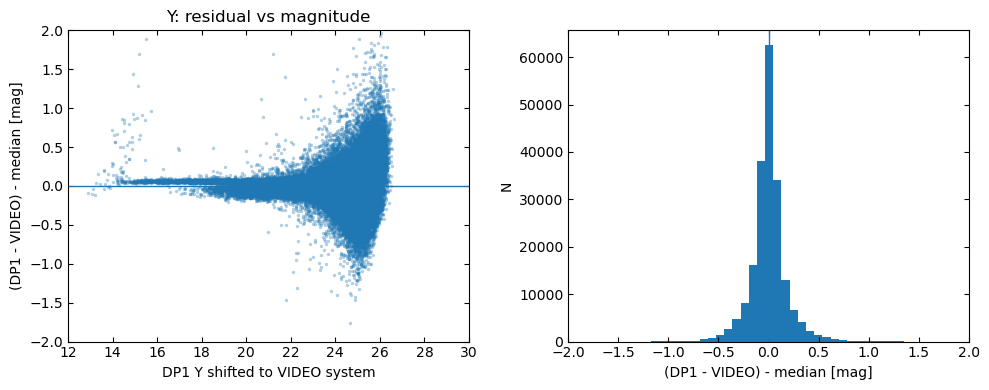

Y band
  VIDEO column: Y_MAG_APER_2
  magErr threshold: 0.217
  N: 199743
  median(DP1 - VIDEO): 0.07224383029938863
  NMAD(res): 0.10675934667083972
  bright N (DP1 shifted mag < 18): 893
  bright NMAD(res): 0.015737523375071266
  bright frac |res| > 0.3: 0.04143337066069429


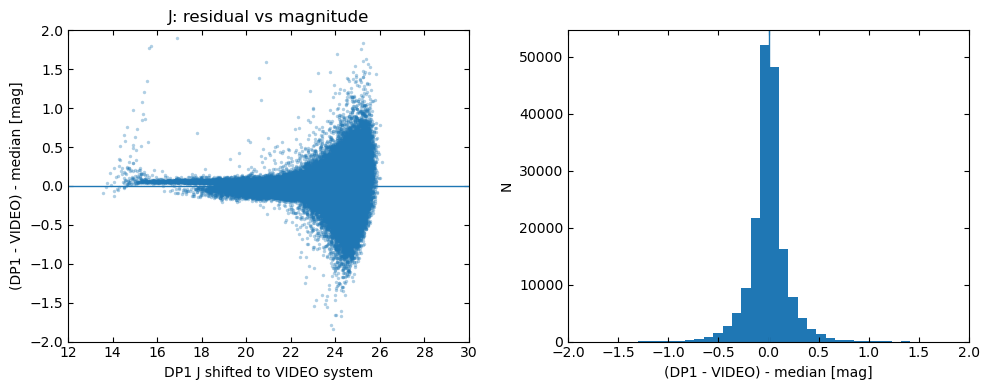

J band
  VIDEO column: J_MAG_APER_2
  magErr threshold: 0.217
  N: 175655
  median(DP1 - VIDEO): 0.05849368587130499
  NMAD(res): 0.1120135275168188
  bright N (DP1 shifted mag < 18): 1000
  bright NMAD(res): 0.014479197769632475
  bright frac |res| > 0.3: 0.029


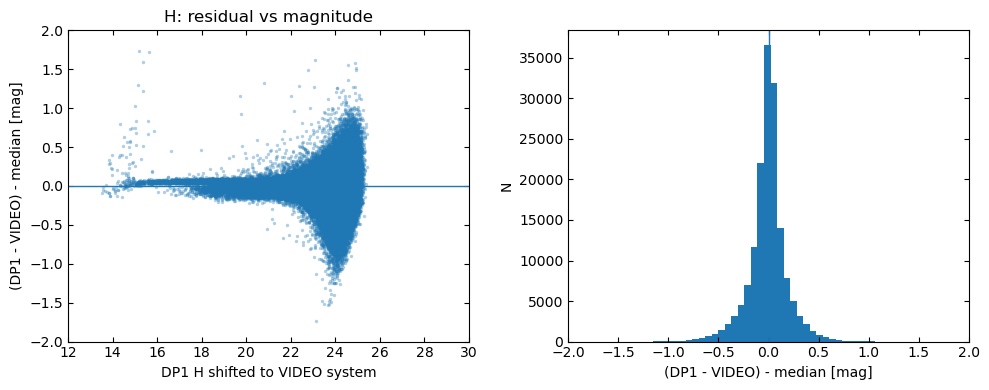

H band
  VIDEO column: H_MAG_APER_2
  magErr threshold: 0.217
  N: 159328
  median(DP1 - VIDEO): 0.06075923522228166
  NMAD(res): 0.11700622141656948
  bright N (DP1 shifted mag < 18): 1102
  bright NMAD(res): 0.01985078464373957
  bright frac |res| > 0.3: 0.03176043557168784


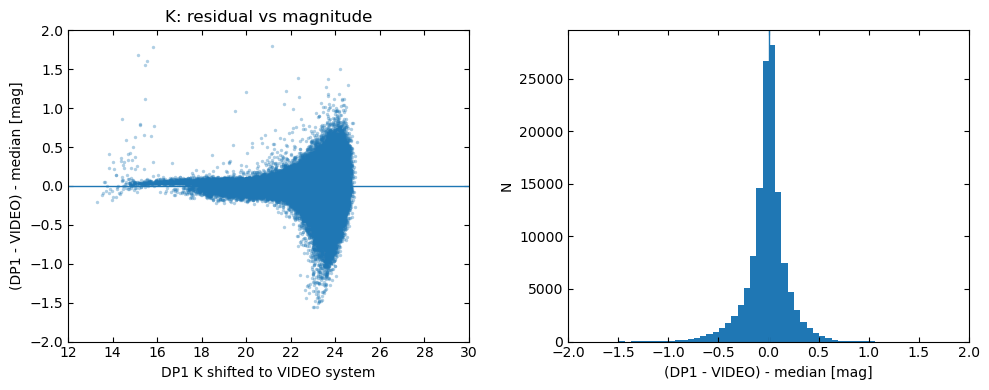

K band
  VIDEO column: KS_MAG_APER_2
  magErr threshold: 0.217
  N: 129576
  median(DP1 - VIDEO): 0.060255232154299065
  NMAD(res): 0.1178665852617166
  bright N (DP1 shifted mag < 18): 1041
  bright NMAD(res): 0.02390372659927916
  bright frac |res| > 0.3: 0.024975984630163303


In [11]:
def video_cols(prefix, aper=VIDEO_APER):
    return {
        "mag":  f"{prefix}_MAG_APER_{aper}",
        "err":  f"{prefix}_MAGERR_APER_{aper}",
        "flag": f"{prefix}_FLAGS",
    }


def video_good_mask(tab, prefix, aper=VIDEO_APER, err_lim=MAGERR_5SIG, require_flag=True):
    cols = video_cols(prefix, aper=aper)

    if not has_col(tab, cols["mag"]):
        raise KeyError(f"Missing VIDEO magnitude column: {cols['mag']}")

    mag = arr(tab, cols["mag"], float)

    if has_col(tab, cols["err"]):
        err = arr(tab, cols["err"], float)
        m = np.isfinite(mag) & np.isfinite(err) & (err > 0) & (err < err_lim)
    else:
        m = np.isfinite(mag)

    if require_flag and has_col(tab, cols["flag"]):
        flag = arr(tab, cols["flag"], int)
        m &= (flag == 0)

    return m


def compare_residual_band(
    band,
    aper=VIDEO_APER,
    dp1_to_video_offset=DP1_TO_VIDEO_OFFSET,
    err_lim=MAGERR_5SIG,
    xlim=(12, 30),
    ylim=(-2, 2),
):
    if band not in VIDEO_PREFIX:
        raise ValueError(f"No VIDEO mapping for band {band}")

    vprefix = VIDEO_PREFIX[band]
    vcols = video_cols(vprefix, aper=aper)

    if not has_col(vid_box, vcols["mag"]):
        print(f"Skipping {band}: missing VIDEO column {vcols['mag']}")
        return None

    dp1_m = dp1_mag(dp1c, band) - dp1_to_video_offset
    dp1_good = dp1_band_usable(dp1c, band, err_lim=err_lim, require_coverage=True)

    vid_m_all = arr(vid_box, vcols["mag"], float)
    vid_good_all = video_good_mask(vid_box, vprefix, aper=aper, err_lim=err_lim, require_flag=True)

    good = (
        matched
        & dp1_good
        & vid_good_all[idx]
        & np.isfinite(dp1_m)
        & np.isfinite(vid_m_all[idx])
    )

    # Recommended stricter-but-not-too-aggressive validation cuts
    good &= sep.arcsec < 0.35
    good &= keep_closest_dp1_per_video_match(good)

    if good.sum() == 0:
        print(f"{band}: no good matched sources")
        return None

    dm = dp1_m[good] - vid_m_all[idx[good]]
    const = np.nanmedian(dm)
    res = dm - const
    mag_plot = dp1_m[good]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].scatter(mag_plot, res, s=6, alpha=0.35, linewidths=0)
    axes[0].axhline(0, lw=1)
    axes[0].set_xlim(*xlim)
    axes[0].set_ylim(*ylim)
    axes[0].set_xlabel(f"DP1 {band} shifted to VIDEO system")
    axes[0].set_ylabel("(DP1 - VIDEO) - median [mag]")
    axes[0].set_title(f"{band}: residual vs magnitude")
    axes[0].tick_params(direction="in", top=True, right=True)

    axes[1].hist(res[np.isfinite(res)], bins=60)
    axes[1].axvline(0, lw=1)
    axes[1].set_xlim(*ylim)
    axes[1].set_xlabel("(DP1 - VIDEO) - median [mag]")
    axes[1].set_ylabel("N")
    axes[1].tick_params(direction="in", top=True, right=True)

    plt.tight_layout()
    savefig(f"dp1_video_{band}_residuals.png")
    plt.show()

    print(f"{band} band")
    print("  VIDEO column:", vcols["mag"])
    print(f"  magErr threshold: {err_lim:.3f}")
    print("  N:", int(good.sum()))
    print("  median(DP1 - VIDEO):", float(const))
    print("  NMAD(res):", float(nmad(res)))

    bright = mag_plot < 18
    if bright.sum() > 0:
        print("  bright N (DP1 shifted mag < 18):", int(bright.sum()))
        print("  bright NMAD(res):", float(nmad(res[bright])))
        print("  bright frac |res| > 0.3:", float(np.mean(np.abs(res[bright]) > 0.3)))

    return {
        "band": band,
        "mask": good,
        "mag": mag_plot,
        "res": res,
        "median": const,
        "nmad": nmad(res),
    }


residual_results = {}
for band in ["Y", "J", "H", "K"]:
    try:
        result = compare_residual_band(band, err_lim=MAGERR_5SIG)
        if result is not None:
            residual_results[band] = result
    except Exception as e:
        print(f"Skipping {band} because of error:")
        print(type(e).__name__, e)

### 6.1 Residual summary table (Stronger match-quality)


In [12]:
print("Band   N       median(DP1-VIDEO)    NMAD")
for band, result in residual_results.items():
    print(
        f"{band:4s} "
        f"{len(result['res']):7d} "
        f"{result['median']:18.5f} "
        f"{result['nmad']:10.5f}"
    )

Band   N       median(DP1-VIDEO)    NMAD
Y     199743            0.07224    0.10676
J     175655            0.05849    0.11201
H     159328            0.06076    0.11701
K     129576            0.06026    0.11787


### 7. VIDEO-star stellar-offset
This diagnostic uses only high-quality VIDEO stars to estimate a single constant K-band offset between the LSST–VISTA forced photometry and the VIDEO public catalogue. The offset is estimated from stars in a safe magnitude range and then subtracted from the same stellar sample. Therefore the corrected residual distribution should be centred close to zero by construction.

VIDEO-star selection
  CLASS_STAR cut: 0.7
  N VIDEO stars : 26056

Mutual nearest-neighbour matches
  match radius: 0.5 arcsec
  N matched   : 20418
  median sep  : 0.17235646475088173 arcsec
  p90 sep     : 0.31352962995492106 arcsec

After DP1/VIDEO photometric-quality cuts
  N good stellar matches: 6435

VIDEO-star constant offset
  shift range           : 16.0 <= Ks < 20.0
  N stars for shift     : 1046
  offset subtracted     : 0.10681783613029516 mag
  corrected median      : -0.004300182709458866
  corrected NMAD        : 0.050711163683209444
  corrected frac |res|>0.1: 0.1672105672105672
  corrected frac |res|>0.2: 0.05376845376845377


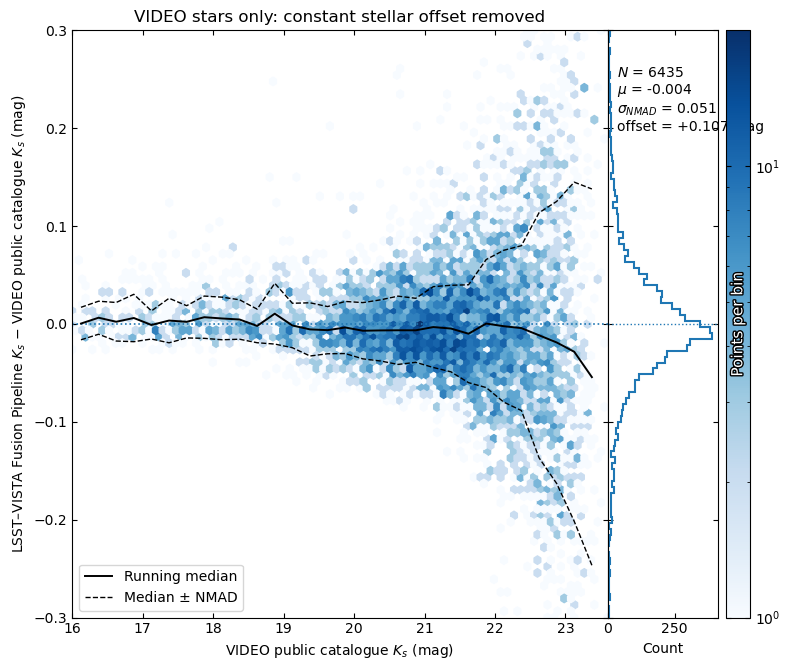

In [13]:
# ============================================================
# VIDEO-star stellar-offset diagnostic: K band
# ============================================================
#
# Purpose:
#   1. Select high-quality VIDEO stars.
#   2. Match them one-to-one with DP1 sources.
#   3. Use the stellar sample to estimate one constant K-band offset.
#   4. Subtract that offset from the same stellar sample.
#   5. Check that the corrected stellar residual distribution is centred
#      very close to zero.
#
# Important:
#   This is a stellar zero-point / consistency diagnostic.
#   It is not the same as the full galaxy+star residual plot.

import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.coordinates import match_coordinates_sky
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.patheffects as pe


# ------------------------------------------------------------
# Small helper functions
# ------------------------------------------------------------

def nmad(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan
    med = np.nanmedian(x)
    return 1.4826 * np.nanmedian(np.abs(x - med))


def running_stats(x, y, bin_edges, min_per_bin=15):
    xc, med, scat, nbin = [], [], [], []

    for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
        m = (
            np.isfinite(x)
            & np.isfinite(y)
            & (x >= lo)
            & (x < hi)
        )

        if m.sum() < min_per_bin:
            continue

        yy = y[m]

        xc.append(0.5 * (lo + hi))
        med.append(np.nanmedian(yy))
        scat.append(nmad(yy))
        nbin.append(m.sum())

    return (
        np.asarray(xc),
        np.asarray(med),
        np.asarray(scat),
        np.asarray(nbin),
    )


def optional_bool_column(tab, col, default=True):
    if col in tab.colnames:
        return np.asarray(tab[col], bool)
    return np.full(len(tab), default, dtype=bool)


def optional_int_column(tab, col, default=0):
    if col in tab.colnames:
        return np.asarray(tab[col], int)
    return np.full(len(tab), default, dtype=int)


# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

DP1_TO_VIDEO_OFFSET = 1.4
MAGERR_5SIG = 2.5 / np.log(10) / 5.0
MATCH_RADIUS = 0.5 * u.arcsec

STAR_CLASS_CUT = 0.7

# Safe magnitude range used to estimate the constant stellar offset.
# This avoids the faintest/noisiest end and the very brightest small-number end.
SHIFT_RANGE = (16.0, 20.0)

# Plot limits
XLIM = (16.0, 23.6)
YLIM = (-0.30, 0.30)


# ------------------------------------------------------------
# Select high-quality VIDEO stars
# ------------------------------------------------------------

ks_cls  = np.asarray(vid_box["KS_CLASS_STAR"], float)
ks_flag = np.asarray(vid_box["KS_FLAGS"], int)
ks_mag  = np.asarray(vid_box["KS_MAG_APER_2"], float)
ks_err  = np.asarray(vid_box["KS_MAGERR_APER_2"], float)

video_star_mask = (
    np.isfinite(ks_cls)
    & np.isfinite(ks_mag)
    & np.isfinite(ks_err)
    & (ks_flag == 0)
    & (ks_err > 0)
    & (ks_err < MAGERR_5SIG)
    & (ks_cls > STAR_CLASS_CUT)
)

vid_star = vid_box[video_star_mask]
c_vid_star = c_vid_box[video_star_mask]

print("VIDEO-star selection")
print("  CLASS_STAR cut:", STAR_CLASS_CUT)
print("  N VIDEO stars :", len(vid_star))


# ------------------------------------------------------------
# Mutual nearest-neighbour match: VIDEO stars <-> DP1
# ------------------------------------------------------------
#
# This is stricter than a simple nearest-neighbour match.
# A pair is kept only if:
#   DP1 nearest VIDEO star = that VIDEO star
#   and VIDEO star nearest DP1 source = that DP1 source.

idx_d2v, sep_d2v, _ = match_coordinates_sky(c_dp1, c_vid_star)
idx_v2d, sep_v2d, _ = match_coordinates_sky(c_vid_star, c_dp1)

video_idx = np.arange(len(c_vid_star))
dp1_idx = idx_v2d

mutual = (
    (sep_v2d < MATCH_RADIUS)
    & (sep_d2v[dp1_idx] < MATCH_RADIUS)
    & (idx_d2v[dp1_idx] == video_idx)
)

video_keep = video_idx[mutual]
dp1_keep = dp1_idx[mutual]

dp1m = dp1c[dp1_keep]
vidm = vid_star[video_keep]

sep_match = sep_v2d[mutual].arcsec

print("\nMutual nearest-neighbour matches")
print("  match radius:", MATCH_RADIUS.to(u.arcsec).value, "arcsec")
print("  N matched   :", len(dp1m))
print("  median sep  :", np.nanmedian(sep_match), "arcsec")
print("  p90 sep     :", np.nanpercentile(sep_match, 90), "arcsec")


# ------------------------------------------------------------
# DP1 and VIDEO K-band photometric-quality cuts
# ------------------------------------------------------------

dp1_k_mag_raw = np.asarray(
    dp1m["VIRCAM_K_m_base_CircularApertureFlux_6_0_mag"],
    float,
)

# Apply the approximate DP1-to-VIDEO system offset first.
dp1_k_mag = dp1_k_mag_raw - DP1_TO_VIDEO_OFFSET

dp1_k_err = np.asarray(
    dp1m["VIRCAM_K_m_base_CircularApertureFlux_6_0_magErr"],
    float,
)

dp1_k_flag = np.asarray(
    dp1m["VIRCAM_K_m_base_CircularApertureFlux_6_0_flag"],
    bool,
)

# Optional DP1 quality columns
dp1_primary = optional_bool_column(
    dp1m,
    "VIRCAM_K_m_detect_isPrimary",
    default=True,
)

dp1_nchild = optional_int_column(
    dp1m,
    "VIRCAM_K_m_deblend_nChild",
    default=0,
)

vid_k_mag = np.asarray(vidm["KS_MAG_APER_2"], float)
vid_k_err = np.asarray(vidm["KS_MAGERR_APER_2"], float)

good_star_match = (
    np.isfinite(dp1_k_mag)
    & np.isfinite(dp1_k_err)
    & np.isfinite(vid_k_mag)
    & np.isfinite(vid_k_err)
    & (dp1_k_err > 0)
    & (vid_k_err > 0)
    & (dp1_k_err < MAGERR_5SIG)
    & (vid_k_err < MAGERR_5SIG)
    & (~dp1_k_flag)
    & dp1_primary
    & (dp1_nchild == 0)
)

x = vid_k_mag[good_star_match]
y_raw = dp1_k_mag[good_star_match] - vid_k_mag[good_star_match]

print("\nAfter DP1/VIDEO photometric-quality cuts")
print("  N good stellar matches:", len(y_raw))


# ------------------------------------------------------------
# Estimate one constant stellar offset
# ------------------------------------------------------------
#
# The offset is estimated from a safe stellar magnitude range.
# Then the same offset is subtracted from the same stellar sample.

shift_mask = (
    np.isfinite(x)
    & np.isfinite(y_raw)
    & (x >= SHIFT_RANGE[0])
    & (x < SHIFT_RANGE[1])
)

if shift_mask.sum() < 20:
    raise RuntimeError(
        f"Too few stars in shift range {SHIFT_RANGE}: "
        f"N={shift_mask.sum()}"
    )

stellar_offset = np.nanmedian(y_raw[shift_mask])

# Corrected stellar residuals
y = y_raw - stellar_offset

print("\nVIDEO-star constant offset")
print(f"  shift range           : {SHIFT_RANGE[0]} <= Ks < {SHIFT_RANGE[1]}")
print("  N stars for shift     :", int(shift_mask.sum()))
print("  offset subtracted     :", float(stellar_offset), "mag")
print("  corrected median      :", float(np.nanmedian(y)))
print("  corrected NMAD        :", float(nmad(y)))
print("  corrected frac |res|>0.1:", float(np.mean(np.abs(y) > 0.1)))
print("  corrected frac |res|>0.2:", float(np.mean(np.abs(y) > 0.2)))


# ------------------------------------------------------------
# Running median and NMAD
# ------------------------------------------------------------

bin_edges = np.arange(XLIM[0], XLIM[1] + 0.0001, 0.25)
xc, ymed, ysig, nbin = running_stats(
    x,
    y,
    bin_edges,
    min_per_bin=10,
)


# ------------------------------------------------------------
# Plot: stellar residuals after subtracting the constant offset
# ------------------------------------------------------------

fig = plt.figure(figsize=(8.0, 6.8))
ax = fig.add_subplot(111)

divider = make_axes_locatable(ax)
ax_r = divider.append_axes("right", size=1.1, pad=0.0, sharey=ax)
cax = divider.append_axes("right", size="4.5%", pad=0.08)

hb = ax.hexbin(
    x,
    y,
    gridsize=80,
    extent=(XLIM[0], XLIM[1], YLIM[0], YLIM[1]),
    mincnt=1,
    bins="log",
    cmap="Blues",
)

ax.axhline(0, lw=1.2, ls=":")

ax.plot(
    xc,
    ymed,
    lw=1.4,
    color="black",
    label="Running median",
)

ax.plot(
    xc,
    ymed + ysig,
    lw=1.0,
    ls="--",
    color="black",
    label="Median ± NMAD",
)

ax.plot(
    xc,
    ymed - ysig,
    lw=1.0,
    ls="--",
    color="black",
)

ax.set_xlim(*XLIM)
ax.set_ylim(*YLIM)

ax.set_xlabel("VIDEO public catalogue $K_s$ (mag)")
ax.set_ylabel(
    "LSST–VISTA Fusion Pipeline $K_s$ − VIDEO public catalogue $K_s$ (mag)"
)

ax.set_title("VIDEO stars only: constant stellar offset removed")
ax.tick_params(direction="in", top=True, right=True)
ax.legend(loc="lower left", frameon=True)

# Right-hand residual histogram
bins_y = np.linspace(YLIM[0], YLIM[1], 100)

ax_r.hist(
    y,
    bins=bins_y,
    histtype="step",
    lw=1.5,
    orientation="horizontal",
)

ax_r.axhline(0, lw=1.0, ls=":")
ax_r.tick_params(direction="in", top=True, right=True, labelleft=False)
ax_r.set_xlabel("Count")

txt = (
    f"$N$ = {len(y)}\n"
    f"$\\mu$ = {np.nanmedian(y):+.3f}\n"
    f"$\\sigma_{{NMAD}}$ = {nmad(y):.3f}\n"
    f"offset = {stellar_offset:+.3f} mag"
)

ax_r.text(
    0.08,
    0.94,
    txt,
    transform=ax_r.transAxes,
    ha="left",
    va="top",
)

# Colour bar
cb = fig.colorbar(hb, cax=cax)
cb.ax.tick_params(which="both", direction="in", right=True, left=True)
cb.set_label("")

cb.ax.text(
    0.5,
    0.5,
    "Points per bin",
    transform=cb.ax.transAxes,
    rotation=90,
    ha="center",
    va="center",
    color="white",
    fontsize=11,
    path_effects=[pe.withStroke(linewidth=2, foreground="black")],
)

plt.tight_layout()
plt.savefig(OUTDIR / "dp1_video_stars_residuals.pdf", dpi=300)
plt.show()

This diagnostic checks the stellar photometric consistency between the LSST–VISTA Fusion Pipeline forced photometry and the VIDEO public catalogue in the `K_s` band.

The comparison is restricted to a clean stellar sample from VIDEO. VIDEO stars are selected using `KS_CLASS_STAR > 0.7`, `KS_FLAGS = 0`, finite `KS_MAG_APER_2` and `KS_MAGERR_APER_2`, positive magnitude errors, and `KS_MAGERR_APER_2 < 0.217`, corresponding approximately to a 5σ photometric-error cut. The VIDEO stellar catalogue is then matched to the DP1 catalogue using a mutual nearest-neighbour match within 0.5 arcsec, so that only one-to-one VIDEO-star/DP1 associations are kept.

On the DP1 side, the comparison uses `VIRCAM_K_m_base_CircularApertureFlux_6_0_mag`. The 1.4 mag shift is an approximate conversion offset used to place the DP1 Jansky-based magnitudes on roughly the same scale as the VIDEO AB magnitudes for diagnostic comparison. Additional DP1 quality cuts require finite magnitude and magnitude error, positive magnitude error, `magErr < 0.217`, an unflagged aperture-flux measurement, `detect_isPrimary = 1`, and `deblend_nChild = 0`. These cuts remove non-primary detections, deblended children, and unreliable aperture measurements.

A constant stellar offset is then estimated using only stars in the safe magnitude range:

```text
16 <= VIDEO Ks < 20
```

This range avoids the very bright low-number regime and the faintest noisy regime. In this run, the offset was estimated from 1046 stars and was:

```text
offset = +0.106 mag
```

This offset is then subtracted from the same stellar sample. Therefore, the corrected residual distribution is expected to be centred close to zero by construction. The running median is close to zero over most of the well-populated magnitude range, showing that a single stellar offset brings the DP1 and VIDEO stellar photometry into good agreement. The scatter increases toward the faint end, especially beyond Ks ~ 22, which is expected because the photometric uncertainties, background noise, and possible blending become more important.

### VIDEO aperture-choice diagnostic for the stellar sample

The previous cell estimated and subtracted one constant stellar offset using VIDEO `KS_MAG_APER_2`. Here I test how the raw DP1–VIDEO stellar residual changes when different VIDEO aperture magnitudes are used.

The same mutual nearest-neighbour VIDEO-star/DP1 matched sample is used. On the DP1 side, I keep primary, non-deblended, unflagged K-band aperture measurements with 5σ magnitude errors. On the VIDEO side, I compare several `KS_MAG_APER_*` columns, each with finite 5σ photometry.

This diagnostic is not a new correction. It is a check of aperture dependence. If different VIDEO apertures give different median residuals, then part of the DP1–VIDEO offset is caused by aperture-definition differences rather than a pure zero-point difference.

DP1 stellar quality base sample
  N matched stellar rows : 20418
  N after DP1 K cuts     : 6435


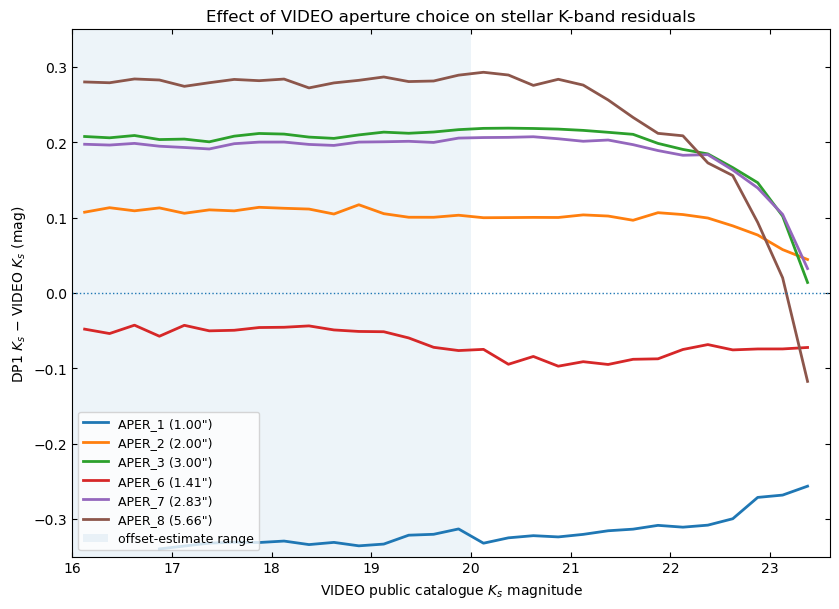


VIDEO aperture-choice summary
Shift-summary range: 16.0 <= Ks < 20.0

aper  diam   N_all   med_all  nmad_all   N_shift  med_shift  nmad_shift
   1  1.00    1490   -0.3073    0.0436       265    -0.3325      0.0186
   2  2.00    6191   +0.1015    0.0498      1044    +0.1067      0.0217
   3  3.00    5899   +0.2082    0.0496      1132    +0.2101      0.0264
   6  1.41    6237   -0.0763    0.0751       900    -0.0532      0.0322
   7  2.83    5976   +0.1969    0.0474      1121    +0.1993      0.0250
   8  5.66    4418   +0.2660    0.0639      1097    +0.2814      0.0308


In [14]:
# ============================================================
# VIDEO aperture-choice diagnostic for the matched stellar sample
# ============================================================
#   dp1m : matched DP1 sources
#   vidm : matched VIDEO stars
#
# The purpose is to see how the raw DP1 - VIDEO residual changes
# when different VIDEO aperture magnitudes are used.

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def nmad(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan
    med = np.nanmedian(x)
    return 1.4826 * np.nanmedian(np.abs(x - med))


def running_stats(x, y, bin_edges, min_per_bin=10):
    xc, med, scat, nbin = [], [], [], []

    for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
        m = (
            np.isfinite(x)
            & np.isfinite(y)
            & (x >= lo)
            & (x < hi)
        )

        if m.sum() < min_per_bin:
            continue

        yy = y[m]

        xc.append(0.5 * (lo + hi))
        med.append(np.nanmedian(yy))
        scat.append(nmad(yy))
        nbin.append(m.sum())

    return (
        np.asarray(xc),
        np.asarray(med),
        np.asarray(scat),
        np.asarray(nbin),
    )


def optional_bool_column(tab, col, default=True):
    if col in tab.colnames:
        return np.asarray(tab[col], bool)
    return np.full(len(tab), default, dtype=bool)


def optional_int_column(tab, col, default=0):
    if col in tab.colnames:
        return np.asarray(tab[col], int)
    return np.full(len(tab), default, dtype=int)


# ------------------------------------------------------------
# Check that this cell is run after the stellar-match cell
# ------------------------------------------------------------

for required_name in ["dp1m", "vidm"]:
    if required_name not in globals():
        raise RuntimeError(
            f"`{required_name}` is not defined. "
            "Run the VIDEO-star stellar-offset cell first."
        )


# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

DP1_TO_VIDEO_OFFSET = 1.4
MAGERR_5SIG = 2.5 / np.log(10) / 5.0

# Safe stellar range used for offset summaries
SHIFT_RANGE = (16.0, 20.0)

# Plot range
XLIM = (16.0, 23.6)
YLIM = (-0.35, 0.35)

# VIDEO aperture numbers and approximate aperture diameters in arcsec.
# These labels are used only for the legend.
apertures = {
    1: 1.00,
    2: 2.00,
    3: 3.00,
    6: 1.41,
    7: 2.83,
    8: 5.66,
}


# ------------------------------------------------------------
# DP1 K-band quality selection
# ------------------------------------------------------------

dp1_k_mag_raw = np.asarray(
    dp1m["VIRCAM_K_m_base_CircularApertureFlux_6_0_mag"],
    float,
)

dp1_k_mag = dp1_k_mag_raw - DP1_TO_VIDEO_OFFSET

dp1_k_err = np.asarray(
    dp1m["VIRCAM_K_m_base_CircularApertureFlux_6_0_magErr"],
    float,
)

dp1_k_flag = np.asarray(
    dp1m["VIRCAM_K_m_base_CircularApertureFlux_6_0_flag"],
    bool,
)

dp1_primary = optional_bool_column(
    dp1m,
    "VIRCAM_K_m_detect_isPrimary",
    default=True,
)

dp1_nchild = optional_int_column(
    dp1m,
    "VIRCAM_K_m_deblend_nChild",
    default=0,
)

base_dp1 = (
    np.isfinite(dp1_k_mag)
    & np.isfinite(dp1_k_err)
    & (dp1_k_err > 0)
    & (dp1_k_err < MAGERR_5SIG)
    & (~dp1_k_flag)
    & dp1_primary
    & (dp1_nchild == 0)
)

print("DP1 stellar quality base sample")
print("  N matched stellar rows :", len(dp1m))
print("  N after DP1 K cuts     :", int(base_dp1.sum()))


# ------------------------------------------------------------
# Compare different VIDEO apertures
# ------------------------------------------------------------

summary_rows = []

fig, ax = plt.subplots(figsize=(8.5, 6.2))

bin_edges = np.arange(XLIM[0], XLIM[1] + 0.001, 0.25)

for aper, diam in apertures.items():

    mag_col = f"KS_MAG_APER_{aper}"
    err_col = f"KS_MAGERR_APER_{aper}"

    if mag_col not in vidm.colnames or err_col not in vidm.colnames:
        print(f"Skipping APER_{aper}: missing {mag_col} or {err_col}")
        continue

    vid_mag = np.asarray(vidm[mag_col], float)
    vid_err = np.asarray(vidm[err_col], float)

    good = (
        base_dp1
        & np.isfinite(vid_mag)
        & np.isfinite(vid_err)
        & (vid_err > 0)
        & (vid_err < MAGERR_5SIG)
    )

    x = vid_mag[good]
    y = dp1_k_mag[good] - vid_mag[good]

    # Restrict only the plotted/statistical range.
    use = (
        np.isfinite(x)
        & np.isfinite(y)
        & (x >= XLIM[0])
        & (x <= XLIM[1])
        & (y >= YLIM[0])
        & (y <= YLIM[1])
    )

    x = x[use]
    y = y[use]

    if len(y) < 30:
        print(f"Skipping APER_{aper}: too few usable stars")
        continue

    xc, ymed, ysig, nbin = running_stats(
        x,
        y,
        bin_edges,
        min_per_bin=10,
    )

    ax.plot(
        xc,
        ymed,
        lw=2,
        label=f"APER_{aper} ({diam:.2f}\")",
    )

    shift_mask = (
        np.isfinite(x)
        & np.isfinite(y)
        & (x >= SHIFT_RANGE[0])
        & (x < SHIFT_RANGE[1])
    )

    summary_rows.append(
        {
            "aper": aper,
            "diam": diam,
            "N_all": len(y),
            "med_all": np.nanmedian(y),
            "nmad_all": nmad(y),
            "N_shift": int(shift_mask.sum()),
            "med_shift": np.nanmedian(y[shift_mask]) if shift_mask.sum() else np.nan,
            "nmad_shift": nmad(y[shift_mask]) if shift_mask.sum() else np.nan,
        }
    )


# ------------------------------------------------------------
# Plot formatting
# ------------------------------------------------------------

ax.axhline(0, lw=1.0, ls=":")
ax.axvspan(
    SHIFT_RANGE[0],
    SHIFT_RANGE[1],
    alpha=0.08,
    label="offset-estimate range",
)

ax.set_xlim(*XLIM)
ax.set_ylim(*YLIM)

ax.set_xlabel("VIDEO public catalogue $K_s$ magnitude")
ax.set_ylabel("DP1 $K_s$ − VIDEO $K_s$ (mag)")
ax.set_title("Effect of VIDEO aperture choice on stellar K-band residuals")
ax.tick_params(direction="in", top=True, right=True)
ax.legend(frameon=True, fontsize=9)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Summary table
# ------------------------------------------------------------

print()
print("VIDEO aperture-choice summary")
print(f"Shift-summary range: {SHIFT_RANGE[0]} <= Ks < {SHIFT_RANGE[1]}")
print()
print("aper  diam   N_all   med_all  nmad_all   N_shift  med_shift  nmad_shift")

for row in summary_rows:
    print(
        f"{row['aper']:>4d}  "
        f"{row['diam']:>4.2f}  "
        f"{row['N_all']:>6d}  "
        f"{row['med_all']:>+8.4f}  "
        f"{row['nmad_all']:>8.4f}  "
        f"{row['N_shift']:>8d}  "
        f"{row['med_shift']:>+9.4f}  "
        f"{row['nmad_shift']:>10.4f}"
    )

- The aperture-choice diagnostic shows how the raw DP1–VIDEO stellar residual depends on the VIDEO aperture definition. This is useful because the stellar-offset correction is estimated using one selected VIDEO aperture, while different aperture choices can change the median DP1–VIDEO residual. Therefore, the constant offset should be interpreted as an aperture-dependent stellar alignment term, not only as a pure photometric zero-point.

### 8. The magnitude histogram comparison

This uses the same per-band quality logic. The example below is for K, but the helper can be reused for Y/J/H

- Full cleaned plot  = all good DP1 objects and all good VIDEO objects independently.
This compares all good DP1 sources with all good VIDEO sources. It is not one-to-one, but it is the correct one for catalogue distribution.
- Matched plot       = same objects only, one-to-one, sep < 0.35, closest match kept.
So every DP1 object in the histogram has a corresponding VIDEO object, and every VIDEO value plotted is the matched counterpart. It is not a completeness plot.

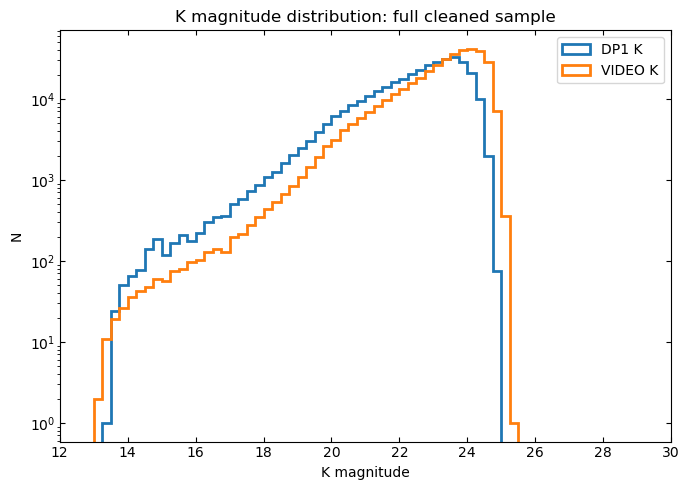

K histogram mode: full cleaned sample
DP1 K N: 351845
VIDEO K N: 384103


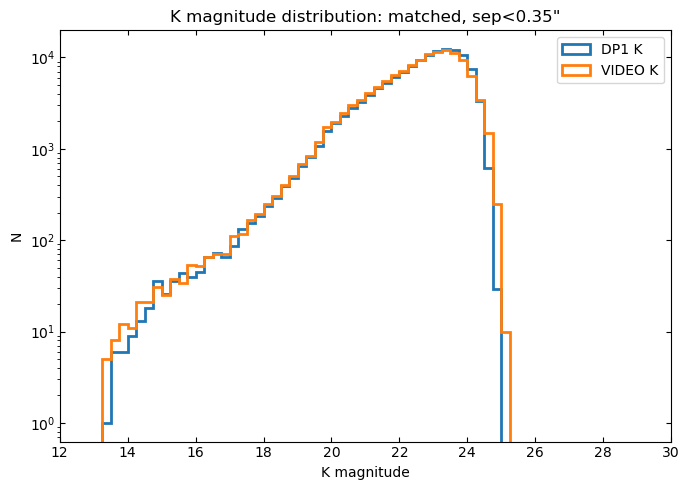

K histogram mode: matched, sep<0.35"
DP1 K N: 129576
VIDEO K N: 129576


In [15]:
def plot_histogram_comparison(
    band,
    aper=VIDEO_APER,
    err_lim=MAGERR_5SIG,
    dp1_to_video_offset=DP1_TO_VIDEO_OFFSET,
    matched_only=False,
    match_sep_arcsec=0.35,
    keep_closest_match=True,
):
    if band not in VIDEO_PREFIX:
        raise ValueError(f"No VIDEO mapping for {band}")

    vprefix = VIDEO_PREFIX[band]
    vcols = video_cols(vprefix, aper=aper)

    dp1_m = dp1_mag(dp1c, band) - dp1_to_video_offset
    dp1_good = dp1_band_usable(
        dp1c,
        band,
        err_lim=err_lim,
        require_coverage=True,
    )

    vid_m_all = arr(vid_box, vcols["mag"], float)
    vid_good_all = video_good_mask(
        vid_box,
        vprefix,
        aper=aper,
        err_lim=err_lim,
        require_flag=True,
    )

    if matched_only:
        # Same logic as residual-validation sample
        good = (
            matched
            & dp1_good
            & vid_good_all[idx]
            & np.isfinite(dp1_m)
            & np.isfinite(vid_m_all[idx])
        )

        if match_sep_arcsec is not None:
            good &= sep.arcsec < match_sep_arcsec

        if keep_closest_match:
            good &= keep_closest_dp1_per_video_match(good)

        dp1_plot = dp1_m[good]
        vid_plot = vid_m_all[idx[good]]

        label_suffix = (
            f"matched, sep<{match_sep_arcsec:.2f}\""
            if match_sep_arcsec is not None
            else "matched"
        )

    else:
        # Full cleaned catalogue comparison, not matched one-to-one
        dp1_plot = dp1_m[dp1_good & np.isfinite(dp1_m)]
        vid_plot = vid_m_all[vid_good_all & np.isfinite(vid_m_all)]

        label_suffix = "full cleaned sample"

    bins = np.arange(12, 30.1, 0.25)

    plt.figure(figsize=(7, 5))

    plt.hist(
        dp1_plot,
        bins=bins,
        histtype="step",
        lw=2,
        label=f"DP1 {band}",
    )

    plt.hist(
        vid_plot,
        bins=bins,
        histtype="step",
        lw=2,
        label=f"VIDEO {band}",
    )

    plt.xlabel(f"{band} magnitude")
    plt.ylabel("N")
    plt.title(f"{band} magnitude distribution: {label_suffix}")
    plt.yscale("log")
    plt.legend()

    ax = plt.gca()
    ax.set_xlim(12, 30)
    ax.tick_params(direction="in", top=True, right=True)

    plt.tight_layout()

    if matched_only:
        savefig(f"dp1_video_{band}_histogram_matched.png")
    else:
        savefig(f"dp1_video_{band}_histogram_full_cleaned.png")

    plt.show()

    print(f"{band} histogram mode:", label_suffix)
    print(f"DP1 {band} N:", int(len(dp1_plot)))
    print(f"VIDEO {band} N:", int(len(vid_plot)))

plot_histogram_comparison("K", matched_only=False)
plot_histogram_comparison("K", matched_only=True, match_sep_arcsec=0.35)

### Useful extra check

To understand where objects are lost:

In [16]:
def match_count_ladder(band, aper=VIDEO_APER, err_lim=MAGERR_5SIG):
    vprefix = VIDEO_PREFIX[band]
    vcols = video_cols(vprefix, aper=aper)

    dp1_m = dp1_mag(dp1c, band) - DP1_TO_VIDEO_OFFSET
    dp1_good = dp1_band_usable(dp1c, band, err_lim=err_lim, require_coverage=True)

    vid_m_all = arr(vid_box, vcols["mag"], float)
    vid_good_all = video_good_mask(
        vid_box, vprefix, aper=aper, err_lim=err_lim, require_flag=True
    )

    base = (
        matched
        & dp1_good
        & vid_good_all[idx]
        & np.isfinite(dp1_m)
        & np.isfinite(vid_m_all[idx])
    )

    sep05 = base & (sep.arcsec < 0.50)
    sep035 = base & (sep.arcsec < 0.35)

    closest035 = sep035 & keep_closest_dp1_per_video_match(sep035)

    print(f"{band} count ladder")
    print("Full cleaned DP1       :", int((dp1_good & np.isfinite(dp1_m)).sum()))
    print("Full cleaned VIDEO     :", int((vid_good_all & np.isfinite(vid_m_all)).sum()))
    print("Matched, sep < 0.50    :", int(sep05.sum()))
    print("Matched, sep < 0.35    :", int(sep035.sum()))
    print("sep < 0.35 + closest   :", int(closest035.sum()))

match_count_ladder("K")

K count ladder
Full cleaned DP1       : 351845
Full cleaned VIDEO     : 384103
Matched, sep < 0.50    : 285558
Matched, sep < 0.35    : 265178
sep < 0.35 + closest   : 129576


- The separation cut from 0.50" to 0.35" removes only a modest fraction of matches. The largest reduction comes from enforcing one closest DP1 source per VIDEO object, which removes about half of the sep < 0.35" sample. This indicates that many DP1 sources share the same nearest VIDEO counterpart, probably because of differences in resolution and deblending. Therefore the closest-match filter is useful as a strict diagnostic for ambiguous matches, but it is too aggressive for the main number-count and residual validation plots.


### 9. The colour-colour plots

Each colour-colour plot uses only the bands involved in that plot. For example, `g-i` versus `J-K` requires usable `g`, `i`, `J`, and `K`; a NIR-only plot does not reject a source because of missing optical coverage.

I only use masks for the bands that define the plot. For example:

```python
# g-i versus J-K
mask = good_g & good_i & good_J & good_K

# Y-J versus J-K
mask = good_Y & good_J & good_K
```

In [17]:
from matplotlib.colors import LogNorm

def colour_plot_mask(x_bands, y_bands, xlim=None, ylim=None, err_lim=MAGERR_5SIG):
    """
    Build a clean mask for one colour-colour diagnostic.

    Only the bands used in the plot are required to pass the per-band
    quality mask. This avoids removing real sources globally because
    one unrelated band is bad.
    """
    used_bands = sorted(set(list(x_bands) + list(y_bands)))

    mask = np.ones(len(dp1c), dtype=bool)

    for band in used_bands:
        mask &= dp1_band_usable(
            dp1c,
            band,
            err_lim=err_lim,
            require_coverage=True,
        )

    x = dp1_colour(dp1c, x_bands[0], x_bands[1])
    y = dp1_colour(dp1c, y_bands[0], y_bands[1])

    mask &= np.isfinite(x) & np.isfinite(y)

    if xlim is not None:
        mask &= (x > xlim[0]) & (x < xlim[1])

    if ylim is not None:
        mask &= (y > ylim[0]) & (y < ylim[1])

    return x, y, mask


def plot_colour_colour(x_bands, y_bands, xlim, ylim, title, bins=180, err_lim=MAGERR_5SIG):
    x, y, mask = colour_plot_mask(
        x_bands,
        y_bands,
        xlim=xlim,
        ylim=ylim,
        err_lim=err_lim,
    )

    print("\n" + title)
    print("  bands used:", sorted(set(list(x_bands) + list(y_bands))))
    print("  N selected:", int(mask.sum()))

    plt.figure(figsize=(6.5, 6))
    plt.hist2d(
        x[mask],
        y[mask],
        bins=bins,
        range=[xlim, ylim],
        cmap="Greys",
        cmin=1,
        norm=LogNorm(vmin=1),
    )

    plt.xlabel(f"{x_bands[0]} - {x_bands[1]}")
    plt.ylabel(f"{y_bands[0]} - {y_bands[1]}")
    plt.title(title)
    plt.colorbar(label="Number of sources")
    plt.gca().tick_params(direction="in", top=True, right=True)
    plt.tight_layout()

    fname = title.lower().replace(" ", "_").replace(":", "").replace("/", "_") + ".png"
    savefig(fname)

    plt.show()

    return mask


Clean colour-colour: g-i versus J-K
  bands used: ['J', 'K', 'g', 'i']
  N selected: 95374


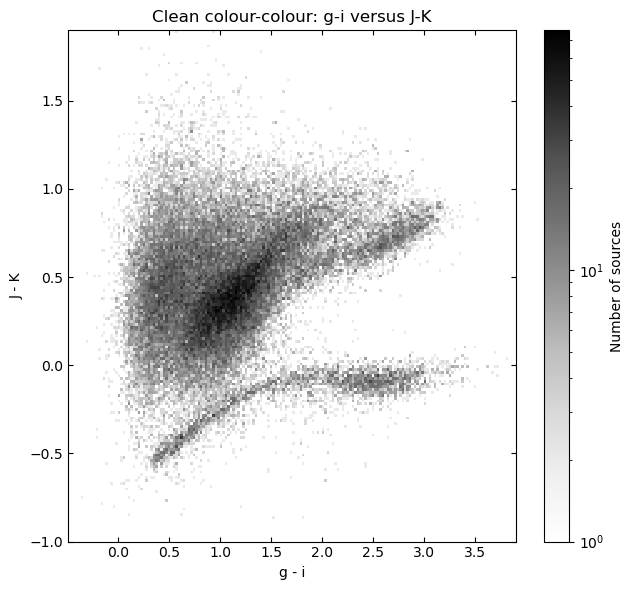

In [18]:
m_gi_JK = plot_colour_colour(
    x_bands=("g", "i"),
    y_bands=("J", "K"),
    xlim=(-0.49, 3.9),
    ylim=(-1.0, 1.9),
    title="Clean colour-colour: g-i versus J-K",
)


Clean colour-colour: u-i versus J-K
  bands used: ['J', 'K', 'i', 'u']
  N selected: 17175


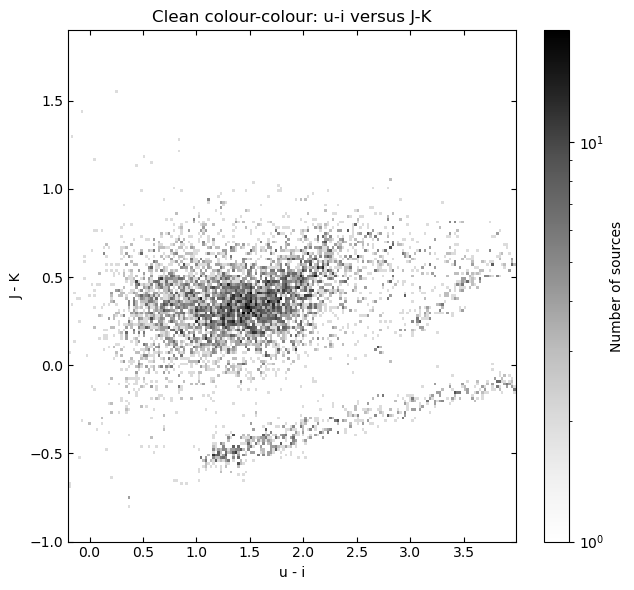

In [19]:
try:
    m_ui_JK = plot_colour_colour(
        x_bands=("u", "i"),
        y_bands=("J", "K"),
        xlim=(-0.2, 3.99),
        ylim=(-1.0, 1.9),
        title="Clean colour-colour: u-i versus J-K",
    )
except KeyError as e:
    print("Skipping u-i versus J-K because a required column is missing:")
    print(e)


Clean colour-colour: r-i versus J-K
  bands used: ['J', 'K', 'i', 'r']
  N selected: 105681


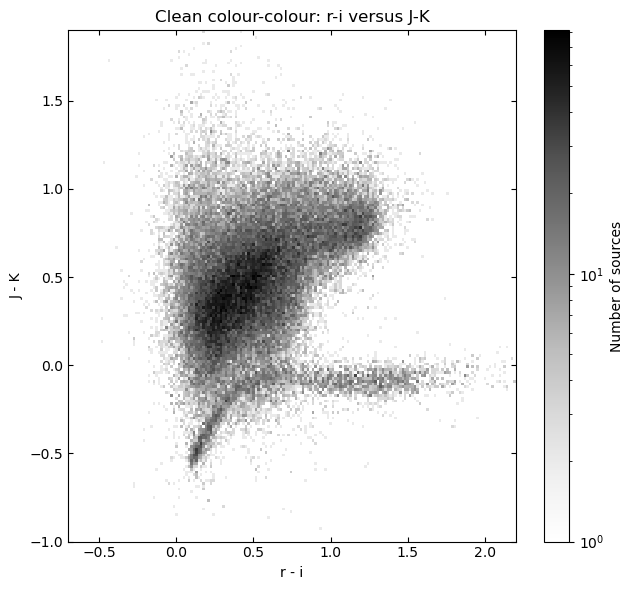

In [20]:
try:
    m_ri_JK = plot_colour_colour(
        x_bands=("r", "i"),
        y_bands=("J", "K"),
        xlim=(-0.7, 2.2),
        ylim=(-1.0, 1.9),
        title="Clean colour-colour: r-i versus J-K",
    )
except KeyError as e:
    print("Skipping r-i versus J-K because a required column is missing:")
    print(e)


Clean optical colour-colour: g-r versus r-i
  bands used: ['g', 'i', 'r']
  N selected: 239960


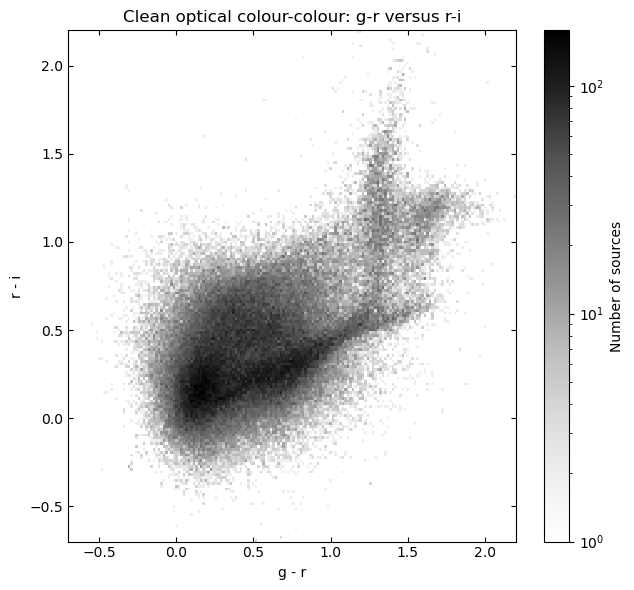

In [21]:
try:
    m_gr_ri = plot_colour_colour(
        x_bands=("g", "r"),
        y_bands=("r", "i"),
        xlim=(-0.7, 2.2),
        ylim=(-0.7, 2.2),
        title="Clean optical colour-colour: g-r versus r-i",
    )
except KeyError as e:
    print("Skipping g-r versus r-i because a required column is missing:")
    print(e)


Clean NIR colour-colour: Y-J versus J-K
  bands used: ['J', 'K', 'Y']
  N selected: 239211


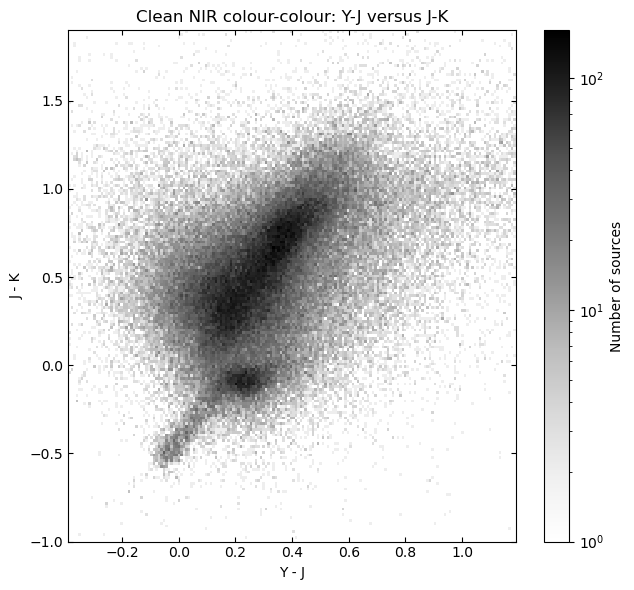

In [22]:
try:
    m_YJ_JK = plot_colour_colour(
        x_bands=("Y", "J"),
        y_bands=("J", "K"),
        xlim=(-0.39, 1.19),
        ylim=(-1.0, 1.9),
        title="Clean NIR colour-colour: Y-J versus J-K",
    )
except KeyError as e:
    print("Skipping Y-J versus J-K because a required column is missing:")
    print(e)

### 10. Baldry-like diagnostic using clean per-band cuts

This is a cleaned version of the stellar-locus style diagnostic (Baldry et al. 2010). It uses the same per-band quality logic and does not manually shift or jitter the colours to hide structures.

The empirical stellar locus is fit only for display/diagnostic purposes from point-like sources.

N selected: 18638
extendedness column: ComCam_i_m_base_ClassificationExtendedness_value
primary column: VIRCAM_K_m_detect_isPrimary


/tmp/ipykernel_19916/199446334.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


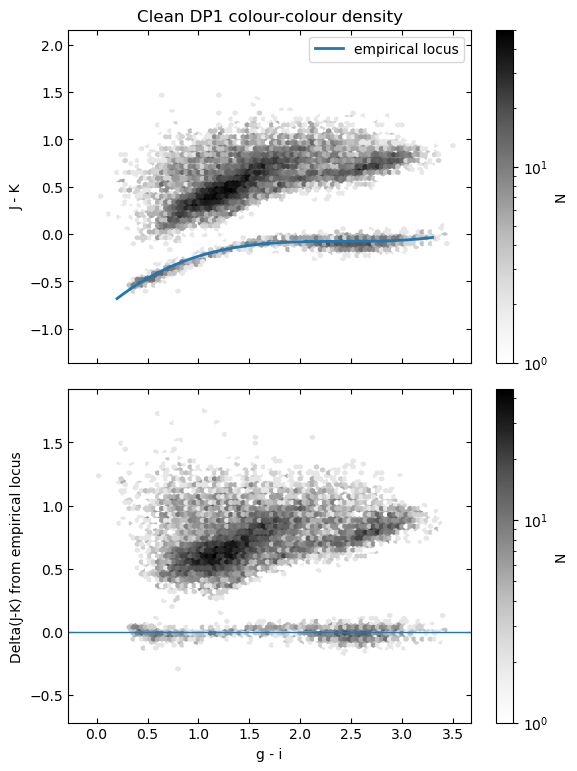

In [23]:
def get_optional_column(tab, candidates, dtype=float):
    for col in candidates:
        if has_col(tab, col):
            return np.asarray(tab[col], dtype=dtype), col
    return None, None


ext, ext_col = get_optional_column(
    dp1c,
    [
        "ComCam_i_m_base_ClassificationExtendedness_value",
        "ComCam_i_m_base_ClassificationExtendedness_value",
        "VIRCAM_K_m_base_ClassificationExtendedness_value",
    ],
    dtype=float,
)

primary, primary_col = get_optional_column(
    dp1c,
    [
        "VIRCAM_K_m_detect_isPrimary",
        "ComCam_i_m_detect_isPrimary",
    ],
    dtype=bool,
)

mask = (
    dp1_band_usable(dp1c, "g", err_lim=0.30, require_coverage=True)
    & dp1_band_usable(dp1c, "i", err_lim=0.30, require_coverage=True)
    & dp1_band_usable(dp1c, "J", err_lim=0.30, require_coverage=True)
    & dp1_band_usable(dp1c, "K", err_lim=0.30, require_coverage=True)
)

if primary is not None:
    mask &= primary

if ext is not None:
    mask &= np.isfinite(ext)

mask &= dp1_mag(dp1c, "K") < 23.5

gi = dp1_colour(dp1c, "g", "i")
JK = dp1_colour(dp1c, "J", "K")

mask &= (
    np.isfinite(gi)
    & np.isfinite(JK)
    & (gi > -1.0)
    & (gi < 3.5)
    & (JK > -1.0)
    & (JK < 2.0)
)

print("N selected:", int(mask.sum()))
print("extendedness column:", ext_col)
print("primary column:", primary_col)

gi_m = gi[mask]
JK_m = JK[mask]

if ext is not None:
    ext_m = ext[mask]
    star_like = ext_m < 0.5
else:
    # If no morphology column is available, use all sources to define a rough locus.
    star_like = np.ones(len(gi_m), dtype=bool)

bins = np.arange(0.2, 3.31, 0.10)
xc = 0.5 * (bins[:-1] + bins[1:])
med = np.full(len(xc), np.nan)
npt = np.zeros(len(xc), dtype=int)

for ii in range(len(xc)):
    mbin = star_like & (gi_m >= bins[ii]) & (gi_m < bins[ii + 1])
    npt[ii] = int(mbin.sum())
    if npt[ii] >= 30:
        med[ii] = np.nanmedian(JK_m[mbin])

ok = np.isfinite(med)
if ok.sum() >= 4:
    coef = np.polyfit(xc[ok], med[ok], deg=3)
    poly = np.poly1d(coef)
    delta = JK_m - poly(gi_m)
else:
    poly = None
    delta = np.full(len(gi_m), np.nan)

fig, axes = plt.subplots(
    2, 1,
    figsize=(6.5, 9),
    sharex=True,
    gridspec_kw={"hspace": 0.08},
)

hb0 = axes[0].hexbin(
    gi_m,
    JK_m,
    gridsize=90,
    extent=(-0.1, 3.5, -1.2, 2.0),
    mincnt=1,
    cmap="Greys",
    norm=LogNorm(),
)
axes[0].set_ylabel("J - K")
axes[0].set_title("Clean DP1 colour-colour density")
axes[0].tick_params(direction="in", top=True, right=True)
fig.colorbar(hb0, ax=axes[0], label="N")

if poly is not None:
    xline = np.linspace(0.2, 3.3, 300)
    axes[0].plot(xline, poly(xline), lw=2, label="empirical locus")
    axes[0].legend(loc="best")

hb1 = axes[1].hexbin(
    gi_m,
    delta,
    gridsize=90,
    extent=(-0.1, 3.5, -0.6, 1.8),
    mincnt=1,
    cmap="Greys",
    norm=LogNorm(),
)
axes[1].axhline(0, lw=1)
axes[1].set_xlabel("g - i")
axes[1].set_ylabel("Delta(J-K) from empirical locus")
axes[1].tick_params(direction="in", top=True, right=True)
fig.colorbar(hb1, ax=axes[1], label="N")

plt.tight_layout()
savefig("dp1_clean_baldry_like_colour_diagnostic.png")
plt.show()